In [ ]:
%load_ext autoreload
%autoreload 2
from __future__ import annotations
import os
import cProfile
import pstats

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from memory_profiler import memory_usage
from time import perf_counter

import gudhi
from gudhi import CubicalComplex
import cripser
import dionysus as dion

from topo.persistence_1d import find_extrema_in_timeseries, compute_1d_sublevel_persistence, compute_batch_sublevel_persistence, \
    StreamingSublevelPersistence, BatchStreamingSublevelPersistence
from topo.utils import DataGenerator1D, DataGenerator2D, MemoryUtils

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
"💾 memory cleanup"
MemoryUtils.clear_jupyter_state()

MemoryUtils.clear_runtime_memory()

MemoryUtils.clear_compilation_cache()


In [ ]:
"[1d or 2d] 📊 Load real datasets"
df       = pd.read_csv("datasets/1D/NVidia_stock_history.csv")
y_vals_t = torch.tensor(df["Close"].values, dtype=torch.float32)#, device=device)

y_vals_flat = y_vals_t.repeat(1, 200).flatten()
y_vals = F.avg_pool1d(y_vals_flat.unsqueeze(0).unsqueeze(0), kernel_size=50, stride=1,).squeeze()
print(y_vals.shape, y_vals_t.shape)

# df     = pd.read_csv("../public_datasets/2D/tabular/longterm_weather/longterm_weather.csv")
# y_vals = torch.tensor(df["rh"].values, dtype=torch.float32)#, device=device)
y_new   = y_vals[:200]
y_new2  = y_vals[:200]
y_vals.shape
num_timesteps = y_vals.shape[0]
num_timesteps_new = num_timesteps
end_point = num_timesteps - 1


In [ ]:
"✅ [1D] setup, function-based"
matplotlib.rcParams['text.usetex'] = False

start_point   = 0
num_timesteps = 800_000
end_point     = num_timesteps//1
y_vals        = DataGenerator1D.make_yvals_1d(num_timesteps, start_point, end_point)

# num_timesteps_new = 100_000
# start_point_new   = end_point + 1
# end_point_new     = start_point_new+num_timesteps_new
# y_new = DataGenerator1D.make_yvals_1d(num_timesteps_new, start_point_new, end_point_new)

# num_timesteps_new2 = 100_000
# start_point_new2   = end_point_new + 1
# end_point_new2     = start_point_new2 + num_timesteps_new2
# y_new2 = DataGenerator1D.make_yvals_1d(num_timesteps_new2, start_point_new2, end_point_new2)


In [ ]:
from ucimlrepo import fetch_ucirepo 
  
# household power
individual_household_electric_power_consumption = fetch_ucirepo(id=235)
X = individual_household_electric_power_consumption.data.features
y = individual_household_electric_power_consumption.data.targets

# power
appliances_energy_prediction = fetch_ucirepo(id=374) 
X = appliances_energy_prediction.data.features 
y = appliances_energy_prediction.data.targets 



In [ ]:
"🪑 [1D] benchmarks"

# # ===== 🪷 Gudhi =====
# start_gudhi = perf_counter()
# cc = CubicalComplex(dimensions=y_vals.shape, top_dimensional_cells=y_vals.numpy().flatten())
# cc.compute_persistence(homology_coeff_field=2) # default is 11, but 2 is faster for Z/2Z coefficients
# # pairs = cc.persistence()  # (dimension, (birth, death))

# # gudhi.plot_persistence_diagram(cc.persistence())
# # gudhi.plot_persistence_barcode(cc.persistence())

# # plt.figure()
# # plt.plot(x_vals.numpy(), y_vals.numpy())
# # plt.show()

# endtime_gudhi = perf_counter()
# print(f"🧮 [🪷 gudhi] persistence of {num_timesteps} y vals in {endtime_gudhi - start_gudhi:.4f} s")

# def bench_gudhi():
#     cc = CubicalComplex(dimensions=y_vals.shape, top_dimensional_cells=y_vals.numpy().flatten())
#     return cc.compute_persistence(homology_coeff_field=2) # default is 11, but 2 is faster for Z/2Z coefficients
# peak_mem_gudhi = max(memory_usage(bench_gudhi))
# print(f"💾 [🪷 gudhi] Peak RAM: {peak_mem_gudhi:.2f} MiB")

# start_gudhi2 = perf_counter()
# cc2 = CubicalComplex(dimensions=y_new.shape, top_dimensional_cells=y_new.numpy().flatten())
# cc2.compute_persistence(homology_coeff_field=2)
# # pairs2 = cc2.persistence()
# endtime_gudhi2 = perf_counter()
# print(f"⛓️‍💥 [🪷 gudhi] stream persistence of {num_timesteps_new} y vals in {endtime_gudhi2 - start_gudhi2:.4f} s")


# ===== ⚡️ cripser =====
arr             = y_vals.numpy()  # keep as 1D array, no need to flatten
start_cripser   = perf_counter()

# prof = cProfile.Profile()
# prof.enable()
ph              = cripser.compute_ph(arr, maxdim=0)
# prof.disable()
# stats = pstats.Stats(prof)
# stats.sort_stats("cumtime")
# stats.print_stats(30)

endtime_cripser = perf_counter()
print(f"🧮 [⚡️ cripser] persistence of {num_timesteps} y vals in {endtime_cripser - start_cripser:.4f} s")

# def bench_cripser():
#     return cripser.compute_ph(arr, maxdim=0)
# peak_mem_cripser = max(memory_usage(bench_cripser))

peak_mem_cripser = max(memory_usage(lambda: cripser.compute_ph(arr, maxdim=0)))
print(f"💾 [⚡️ cripser] Peak RAM: {peak_mem_cripser:.2f} MiB")

h0_1d_cripser = ph[ph[:, 0] == 0][:, 1:3]
print(f"CRiPSER 1D Layout -> H0: {len(h0_1d_cripser)} pairs")


# ===== 🦕 Dionysus =====
# start_dionysus = perf_counter()
# f    = dion.fill_freudenthal(y_vals.numpy())
# m    = dion.homology_persistence(f)
# # dgms = dion.init_diagrams(m, f)
# endtime_dionysus = perf_counter()
# print(f"🧮 [🦕 dionysus] persistence of {num_timesteps} y vals in {endtime_dionysus - start_dionysus:.4f} s")

# def bench_dionysus():
#     return dion.homology_persistence(dion.fill_freudenthal(y_vals.numpy()))
# peak_mem_dionysus = max(memory_usage(bench_dionysus))
# print(f"💾 [🦕 dionysus] Peak RAM: {peak_mem_dionysus:.2f} MiB")


In [ ]:
"⏰ [1D] gpu + numba"

# 1. INITIAL BASELINE (Compute & View Pairs)
torch.cuda.synchronize() if device.type == 'cuda' else None
starttime_gpu = perf_counter()

# prof  = cProfile.Profile()
# prof.enable()
keypoint_idx, keypoint_types = find_extrema_in_timeseries(y_vals, device=y_vals.device)
birth_death_pairs_list       = compute_1d_sublevel_persistence(y_vals, keypoint_idx, keypoint_types)
# prof.disable()
# stats = pstats.Stats(prof)
# stats.sort_stats("cumtime")
# stats.print_stats(30)

torch.cuda.synchronize() if device.type == 'cuda' else None
endtime_gpu   = perf_counter()
print(f"🧮 [😎 ours] persistence of {num_timesteps} yvals in {endtime_gpu - starttime_gpu:.4f}s")

# RAM
def bench_gpu():
    kp_idx, kp_types = find_extrema_in_timeseries(y_vals, device=y_vals.device)
    return compute_1d_sublevel_persistence(y_vals, kp_idx, kp_types)
peak_mem = max(memory_usage(bench_gpu))
print(f"💾 Peak RAM: {peak_mem:.2f} MiB")

# GPU VRAM (separate, additional cost)
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats() if device.type == 'cuda' else None
kp_idx, kp_types = find_extrema_in_timeseries(y_vals, device=y_vals.device)
compute_1d_sublevel_persistence(y_vals, kp_idx, kp_types)
torch.cuda.synchronize() if device.type == 'cuda' else None
print(f"💾 Peak VRAM: {torch.cuda.max_memory_allocated()/1024**2:.2f} MiB")

# 2. INITIALIZE STREAMING PIPELINE (Allocate Max Capacity Upfront Once)
total_capacity = len(y_vals) + len(y_new) + len(y_new2) # set total capacity to safely fit everything
online_tda     = StreamingSublevelPersistence(y_vals, keypoint_idx, keypoint_types, max_capacity=total_capacity)

# 3. STREAM CHUNK 1 (y_new)
stream_keypoint_idx, stream_keypoint_types = find_extrema_in_timeseries(y_new, device=y_new.device)

# Guard condition directly inside your notebook runner cell
if stream_keypoint_idx.numel() == 0:
    print(f"ℹ️ stream chunk 1 has no topology features (flat line). Skipping state update.")
    new_birth_death_pairs_list = []
else:
    new_birth_death_pairs_list = online_tda.update_filtration(
        new_y_chunk=y_new,
        stream_keypoint_idx=stream_keypoint_idx,
        stream_keypoint_types=stream_keypoint_types)
endtime_gpu2 = perf_counter()
print(f"⛓️‍💥 stream chunk 1 persistence of {len(y_new)} yvals in {endtime_gpu2 - endtime_gpu:.4f}s")

# 4. STREAM CHUNK 2 (y_new2)
stream_keypoint_idx2, stream_keypoint_types2 = find_extrema_in_timeseries(y_new2, device=y_new2.device)

# Guard condition directly inside your notebook runner cell
if stream_keypoint_idx2.numel() == 0:
    print(f"ℹ️ stream chunk 2 has no topology features (flat line). Skipping state update.")
    new_birth_death_pairs_list2 = []
else:
    new_birth_death_pairs_list2 = online_tda.update_filtration(
        new_y_chunk=y_new2,
        stream_keypoint_idx=stream_keypoint_idx2,
        stream_keypoint_types=stream_keypoint_types2)
endtime_gpu3 = perf_counter()
print(f"⛓️‍💥 stream chunk 2 persistence of {len(y_new2)} yvals in {endtime_gpu3 - endtime_gpu2:.4f}s")


In [ ]:
"[👍 correct] our method 1d"
from topo.persistence_1d_correct import (
    PrefixStreamingPersistence1D,
    compute_1d_streamed_prefix_final,
    compute_1d_prefix_diagrams_by_chunks,
    compute_1d_prefix_diagrams_by_full_recompute,
    print_1d_streaming_work,
    print_1d_topological_activity,
)

n_trials = 3
m_chunks_1d = 10
y_vals_np = y_vals.detach().cpu().numpy().astype('float32') if hasattr(y_vals, 'detach') else np.asarray(y_vals, dtype='float32')
chunk_len_1d = max(1, len(y_vals_np) // m_chunks_1d)

print_1d_streaming_work("Correct full-array", len(y_vals_np))
print_1d_topological_activity("Correct full-array", y_vals_np)

print(f"\n==================== 1D WAY A: CORRECT FULL-ARRAY PREFIX (3x Trials) ====================")

full_1d_times = []
full_1d_mems  = []
full_1d_vms   = []

def bench_1d_correct_full():
    return compute_1d_streamed_prefix_final(y_vals_np, chunk_length=len(y_vals_np))

_ = bench_1d_correct_full()
MemoryUtils.clear_memory()

for trial in range(n_trials):
    MemoryUtils.clear_memory()
    start_full_1d = perf_counter()
    h0_1d_full = compute_1d_streamed_prefix_final(y_vals_np, chunk_length=len(y_vals_np))
    end_full_1d = perf_counter()

    full_1d_times.append(end_full_1d - start_full_1d)
    full_1d_vms.append(MemoryUtils.get_vms_mib())
    full_1d_mems.append(max(memory_usage(bench_1d_correct_full)))

    if trial == n_trials - 1:
        h0_1d_full_len = len(h0_1d_full)
    del h0_1d_full

print(f"\n🧮 [correct 1D full-array] Time:  {np.mean(full_1d_times):.4f} s ± {np.std(full_1d_times):.4f} s")
print(f"💾 [correct 1D full-array] Peak RAM:      {np.mean(full_1d_mems):.2f} MiB ± {np.std(full_1d_mems):.2f} MiB")
print(f"💾 [correct 1D full-array] Virtual (VMS): {np.mean(full_1d_vms):.2f} MiB ± {np.std(full_1d_vms):.2f} MiB")
print(f"Correct 1D Full Layout -> H0: {h0_1d_full_len} pairs")
print(f" & full& {np.mean(full_1d_times):.3f}$\pm${np.std(full_1d_times):.3f} & {np.mean(full_1d_mems):.2f}$\pm${np.std(full_1d_mems):.2f} \\")

print_1d_streaming_work("Correct 1D streamed", len(y_vals_np), chunk_length=chunk_len_1d)

print(f"\n==================== 1D WAY B0: FULL RECOMPUTE EVERY PREFIX (3x Trials) ====================")

recompute_1d_times = []
recompute_1d_mems  = []

def bench_1d_full_recompute_prefixes():
    return compute_1d_prefix_diagrams_by_full_recompute(y_vals_np, chunk_length=chunk_len_1d)[-1]

_ = bench_1d_full_recompute_prefixes()
MemoryUtils.clear_memory()

for trial in range(n_trials):
    MemoryUtils.clear_memory()
    start_recompute_1d = perf_counter()
    h0_1d_recompute = compute_1d_prefix_diagrams_by_full_recompute(y_vals_np, chunk_length=chunk_len_1d)[-1]
    end_recompute_1d = perf_counter()
    recompute_1d_times.append(end_recompute_1d - start_recompute_1d)
    recompute_1d_mems.append(max(memory_usage(bench_1d_full_recompute_prefixes)))
    if trial == n_trials - 1:
        h0_1d_recompute_len = len(h0_1d_recompute)
    del h0_1d_recompute

print(f"\n🧮 [1D full recompute prefixes] Time: {np.mean(recompute_1d_times):.4f} s ± {np.std(recompute_1d_times):.4f} s")
print(f"💾 [1D full recompute prefixes] Peak RAM: {np.mean(recompute_1d_mems):.2f} MiB ± {np.std(recompute_1d_mems):.2f} MiB")
print(f"Full Recompute Prefix Layout -> H0: {h0_1d_recompute_len} pairs")
print_1d_topological_activity("Correct 1D streamed", y_vals_np, chunk_length=chunk_len_1d)

print(f"\n==================== 1D WAY B: CORRECT PREFIX STREAMING (3x Trials) ====================")

stream_1d_times = []
stream_1d_mems  = []
stream_1d_vms   = []

def bench_1d_correct_streaming():
    return compute_1d_prefix_diagrams_by_chunks(y_vals_np, chunk_length=chunk_len_1d)[-1]

_ = bench_1d_correct_streaming()
MemoryUtils.clear_memory()

for trial in range(n_trials):
    MemoryUtils.clear_memory()
    start_stream_1d = perf_counter()

    engine_1d = PrefixStreamingPersistence1D()
    for chunk_idx, start in enumerate(range(0, len(y_vals_np), chunk_len_1d)):
        chunk = y_vals_np[start:start + chunk_len_1d]
        engine_1d.update_chunk(chunk)
        h0_1d_prefix = engine_1d.current_exact_prefix_diagram()
        if trial == 0:
            state = engine_1d.stored_state_summary()
            print(f"  ↳ [Chunk {chunk_idx + 1}] Length {len(chunk)} | prefix H0: {len(h0_1d_prefix)} | stored edges: {state['edges_stored']}")

    end_stream_1d = perf_counter()
    stream_1d_times.append(end_stream_1d - start_stream_1d)
    stream_1d_vms.append(MemoryUtils.get_vms_mib())
    stream_1d_mems.append(max(memory_usage(bench_1d_correct_streaming)))

    if trial == n_trials - 1:
        h0_1d_stream_len = len(h0_1d_prefix)
    del engine_1d, h0_1d_prefix

print(f"\n🧮 [correct 1D prefix streaming] Time:  {np.mean(stream_1d_times):.4f} s ± {np.std(stream_1d_times):.4f} s")
print(f"💾 [correct 1D prefix streaming] Peak RAM:      {np.mean(stream_1d_mems):.2f} MiB ± {np.std(stream_1d_mems):.2f} MiB")
print(f"💾 [correct 1D prefix streaming] Virtual (VMS): {np.mean(stream_1d_vms):.2f} MiB ± {np.std(stream_1d_vms):.2f} MiB")
print(f" & {m_chunks_1d}& {np.mean(stream_1d_times):.3f}$\pm${np.std(stream_1d_times):.3f} & {np.mean(stream_1d_mems):.2f}$\pm${np.std(stream_1d_mems):.2f} \\")

print(f"\nCorrect 1D Streamed Layout -> H0: {h0_1d_stream_len} pairs")
print(f"Prefix speedup vs full recompute: {np.mean(recompute_1d_times) / np.mean(stream_1d_times):.2f}x")
print(f"Full-vs-Stream Match? H0: {'✅' if h0_1d_full_len == h0_1d_stream_len else '❌'}")

try:
    ph_1d_cripser = cripser.compute_ph(y_vals_np, maxdim=0)
    h0_1d_cripser = ph_1d_cripser[ph_1d_cripser[:, 0] == 0][:, 1:3]
    print(f"CRiPSER 1D Layout -> H0: {len(h0_1d_cripser)} pairs")
except Exception as exc:
    print(f"CRiPSER 1D comparison skipped: {exc}")

MemoryUtils.clear_memory()


In [ ]:
"🥋 [1D] MASTER (batching + streaming)"

starttime_master = perf_counter()

# --- STEP 1: Slice your base data into a "Baseline" block and a "Streaming Chunk" block ---
baseline_cutoff = int(len(y_vals) * 0.8)

y_vals_baseline = y_vals[:baseline_cutoff]
y_vals_chunk    = y_vals[baseline_cutoff:]

# --- STEP 2: Build the Initial Baseline 2D Matrix (N = 5) ---
y_batch = torch.stack([
    y_vals_baseline, 
    1.2 * y_vals_baseline, 
    -0.8 * y_vals_baseline, 
    -0.4 + 2.1 * y_vals_baseline, 
    0.2 - 0.1 * y_vals_baseline])

# --- STEP 3: Build your incoming streaming 2D Matrix (N = 5) ---
y_chunk_matrix = torch.stack([
    y_vals_chunk, 
    1.2 * y_vals_chunk, 
    -0.8 * y_vals_chunk, 
    -0.4 + 2.1 * y_vals_chunk, 
    0.2 - 0.1 * y_vals_chunk])

# --- STEP 4: Run the pipeline ---
idx_list, types_list = [], []
for i in range(y_batch.shape[0]):
    idx, types = find_extrema_in_timeseries(y_batch[i], device=y_batch.device)
    idx_list.append(idx)
    types_list.append(types)

# Spin up the global 2D tracking system
batch_online_tda = BatchStreamingSublevelPersistence(y_batch, idx_list, types_list)

# Extract chunk keypoints
new_idx_list, new_types_list = [], []
for i in range(y_chunk_matrix.shape[0]):
    idx, types = find_extrema_in_timeseries(y_chunk_matrix[i], device=y_chunk_matrix.device)
    new_idx_list.append(idx)
    new_types_list.append(types)

# Process the new chunk instantaneously across all 5 channels!
new_batch_pairs = batch_online_tda.append_batch_stream(y_chunk_matrix, new_idx_list, new_types_list)

endtime_master = perf_counter()
print(f"🧮 Persistence of {len(y_vals_chunk)} streaming yvals processed across {y_batch.shape[0]} channels in {endtime_master - starttime_master:.4f}s")

# # --- STEP 5: Verification Printout (Sanity Check) ---
# print("\n🔍 Verification Lookups:")
# for i, single_series_pairs in enumerate(new_batch_pairs):
#     print(f"  Channel #{i}: Found {len(single_series_pairs)} new pairs.")
#     if len(single_series_pairs) > 0:
#         b_idx, d_idx = single_series_pairs[0]  # Check first pair discovered
#         birth_val = batch_online_tda.history_values[i, b_idx]
#         death_val = batch_online_tda.history_values[i, d_idx]
#         print(f"    └─ Sample Pair -> Indices: ({b_idx}, {d_idx}) | Values: ({birth_val:2.3f}, {death_val:2.3f})")



In [ ]:
"[1D] speedup comparer"
N_points = end_point
K        = len(keypoint_idx)

cripser_ops = 2*N_points*np.log2(2*N_points) + 6*N_points
our_ops     = 2*N_points + K*np.log2(K) + 4*K

print(f"{N_points} points, {K} keypoints, {K/N_points*100:.2f}% are keypoints")
print(f"#ops: Cripser={cripser_ops:.2e}, Ours={our_ops:.2e}")

theoretical_speedup = cripser_ops / our_ops
actual_speedup = (endtime_cripser - start_cripser) / (endtime_gpu - starttime_gpu)
speedup_ratio = actual_speedup/theoretical_speedup
speedup_emoji = "🚀" if actual_speedup > theoretical_speedup else "🐌"
print(f"Speedup: theoretical={theoretical_speedup:.2f}x actual={actual_speedup:.2f}x ratio={speedup_ratio:.2f} {speedup_emoji}")


In [ ]:
"📗 [2D] setup"
array_dimensions = (500, 500)
# arr_2d    = DataGenerator2D.generate_random_matrix(*array_dimensions, low=0.0, high=30)
arr_2d_patch    = DataGenerator2D.generate_patchy_matrix(*array_dimensions, device=device, min_val=0.0, max_val=10, smooth_radius=3)
arr_2d_donut    = DataGenerator2D.generate_donut_matrix(*array_dimensions, inner_radius=28, outer_radius=30)
arr_2d    = 1.5*arr_2d_donut + arr_2d_patch
arr_2d_np = arr_2d.numpy()

# # Separate H0 and H1 diagrams
# h0_cripser = ph_2d[ph_2d[:, 0] == 0][:, 1:3]  # Keeps only [Birth, Death]
# h1_cripser = ph_2d[ph_2d[:, 0] == 1][:, 1:3]  # Keeps only [Birth, Death]

# # Print summary to verify profiles
# print(f"CRiPSER # H0: {len(h0_cripser)}, # H1: {len(h1_cripser)}")
# # print("First few H1 pairs:\n", h1_cripser[:3])

plt.imshow(arr_2d, aspect="equal", cmap="viridis")
# plt.imshow(arr_2d[2*len(arr_2d)//3:, :], aspect="equal", cmap="viridis")
plt.axis("off")
plt.colorbar()
plt.show()


In [ ]:
"🪑 [2D] benchmarks"

n_trials  = 3
arr_2d_np = arr_2d.detach().cpu().numpy().astype('float32')
MemoryUtils.clear_memory()

print(f"\n============== RUNNING BASELINE BENCHMARKS (3x Trials) ===============")

# ⚡️ CRIPSER
def run_cripser():
    return cripser.compute_ph(arr_2d_np, maxdim=1)

cripser_times = []
cripser_mems  = []

for trial in range(n_trials):
    MemoryUtils.clear_memory()
    start_cripser_2d   = perf_counter()
    ph_2d              = run_cripser()
    endtime_cripser_2d = perf_counter()
    cripser_times.append(endtime_cripser_2d - start_cripser_2d)
    peak_mem_cripser   = max(memory_usage(run_cripser))
    cripser_mems.append(peak_mem_cripser)
    # del ph_2d

print(f"🧮 [⚡️ cripser] Time:     {np.mean(cripser_times):.4f} s ± {np.std(cripser_times):.4f} s")
print(f"💾 [⚡️ cripser] Peak RAM: {np.mean(cripser_mems):.2f} MiB ± {np.std(cripser_mems):.2f} MiB")
print(f"CubicalRipser & {np.mean(cripser_times):.3f}$\\pm${np.std(cripser_times):.3f} & {np.mean(cripser_mems):.2f}$\\pm${np.std(cripser_mems):.2f} \\")
MemoryUtils.clear_memory()

h0_cripser = ph_2d[ph_2d[:, 0] == 0][:, 1:3]
h1_cripser = ph_2d[ph_2d[:, 0] == 1][:, 1:3]
print(f"CRiPSER Layout -> H0: {len(h0_cripser)} pairs | H1: {len(h1_cripser)} pairs")


# 🪷 GUDHI 
def run_gudhi():
    cc = CubicalComplex(dimensions=arr_2d_np.shape, top_dimensional_cells=arr_2d_np.flatten())
    cc.compute_persistence(homology_coeff_field=2) # default is 11, but 2 is faster for Z/2Z coefficients
    return cc

gudhi_times = []
gudhi_mems  = []

for trial in range(n_trials):
    MemoryUtils.clear_memory()
    start_gudhi_2d   = perf_counter()
    _                = run_gudhi()
    endtime_gudhi_2d = perf_counter()
    gudhi_times.append(endtime_gudhi_2d - start_gudhi_2d)
    peak_mem_gudhi   = max(memory_usage(run_gudhi))
    gudhi_mems.append(peak_mem_gudhi)

print(f"🧮 [🪷 gudhi] Time:     {np.mean(gudhi_times):.4f} s ± {np.std(gudhi_times):.4f} s")
print(f"💾 [🪷 gudhi] Peak RAM: {np.mean(gudhi_mems):.2f} MiB ± {np.std(gudhi_mems):.2f} MiB")
print(f"Gudhi & {np.mean(gudhi_times):.3f}$\\pm$ {np.std(gudhi_times):.3f} & {np.mean(gudhi_mems):.2f}$\\pm${np.std(gudhi_mems):.2f} \\")
MemoryUtils.clear_memory()

pairs_gudhi = _.persistence()
h0_gudhi = [p for p in pairs_gudhi if p[0] == 0]
h1_gudhi = [p for p in pairs_gudhi if p[0] == 1]
print(f"Gudhi Layout -> H0: {len(h0_gudhi)} pairs | H1: {len(h1_gudhi)} pairs")

# 3. Dionysus 2 Benchmark Setup
# def run_dionysus():
#     f = dion.fill_freudenthal(arr_2d_np)
#     return dion.homology_persistence(f)

# dionysus_times = []
# dionysus_mems  = []

# for trial in range(n_trials):
#     MemoryUtils.clear_memory()
#     start_dionysus    = perf_counter()
#     m                 = run_dionysus()
#     endtime_dionysus  = perf_counter()
#     dionysus_times.append(endtime_dionysus - start_dionysus)
#     peak_mem_dionysus = max(memory_usage(run_dionysus))
#     dionysus_mems.append(peak_mem_dionysus)
#     del m

# print(f"🧮 [🦕 dionysus] Time:     {np.mean(dionysus_times):.4f} s ± {np.std(dionysus_times):.4f} s")
# print(f"💾 [🦕 dionysus] Peak RAM: {np.mean(dionysus_mems):.2f} MiB ± {np.std(dionysus_mems):.2f} MiB")
# print("================================================================================\n")
# MemoryUtils.clear_memory()


In [ ]:
"our method 2d"
from topo.persistence_2d import compute_h0_h1_fast, _run_streaming_persistence, prepare_multi_chunk_wrapper
from topo.persistence_2d_correct import print_grid_work, print_adaptive_work

n_trials = 3
m_chunks = 10

print_grid_work("Old global / chunk-packed", arr_2d.shape)
print_adaptive_work("Topology-aware reference", arr_2d.detach().cpu().numpy().astype("float32"))

print(f"\n==================== WAY 1: GLOBAL (3x Trials) ====================")

global_times = []
global_mems  = []

def bench_2d():
    return compute_h0_h1_fast(arr_2d, device=device)

# warmup pass to eliminate initial JIT/numba compilation overhead
_ = bench_2d()
MemoryUtils.clear_memory()

for trial in range(n_trials):
    start_our_2d    = perf_counter()
    h0, h1          = compute_h0_h1_fast(arr_2d, device=device)
    endtime_our_2d  = perf_counter()
    global_times.append(endtime_our_2d - start_our_2d)
    peak_mem_global = max(memory_usage(bench_2d))
    global_mems.append(peak_mem_global)
    
    if trial == n_trials - 1:  # Save dimensions for reference report on last trial
        h0_len, h1_len = len(h0), len(h1)
    del h0, h1
    MemoryUtils.clear_memory()

print(f"🧮 [😎 ours global] Time:     {np.mean(global_times):.4f} s ± {np.std(global_times):.4f} s")
print(f"💾 [😎 ours global] Peak RAM: {np.mean(global_mems):.2f} MiB ± {np.std(global_mems):.2f} MiB")
# print(f"   ↳ # H0 pairs: {h0_len}, # H1 pairs: {h1_len}")
# print(f"Ours & {np.mean(global_times):.3f}$\\pm${np.std(global_times):.3f} & {np.mean(global_mems):.2f}$\\pm${np.std(global_mems):.2f} \\")

print_grid_work("Old simulated streaming", arr_2d.shape, chunk_rows=max(1, arr_2d.shape[0] // m_chunks))

print(f"\n==================== WAY 2: ROW-WISE CHUNK STREAMING (3x Trials) ====================")

stream_times = []
stream_mems  = []
stream_vms   = []

def bench_streaming():
    data_package = prepare_multi_chunk_wrapper(arr_2d, m_chunks=m_chunks)
    return _run_streaming_persistence(data_package)

# Warmup pass to eliminate JIT compilation on streaming loops
_ = bench_streaming()
MemoryUtils.clear_memory()

for trial in range(n_trials):
    MemoryUtils.clear_memory()
    if trial == 0:
        print(f"📦 Simulating stream arrival of {m_chunks} horizontal cuts (Verbose logging on Trial 1)...")
    start_streaming_total = perf_counter()
    chunks                = torch.tensor_split(arr_2d, m_chunks, dim=0)
    packed_chunk_data     = []

    for idx, chunk in enumerate(chunks):
        start_chunk   = perf_counter()
        chunk_package = prepare_multi_chunk_wrapper(chunk, m_chunks=1)
        packed_chunk_data.append(chunk_package)
        end_chunk     = perf_counter()
        if trial == 0:
            print(f"  ↳ 🚰 [Chunk {idx+1}/{m_chunks}] Footprint {chunk.shape[0]}x{chunk.shape[1]} in {end_chunk - start_chunk:.4f}s")

    if trial == 0:
        print(f"⚙️ Executing interface stitching across boundaries and compiling final diagram...")
        
    data_package         = prepare_multi_chunk_wrapper(arr_2d, m_chunks=m_chunks)
    h0_stream, h1_stream = _run_streaming_persistence(data_package)
    end_streaming_total  = perf_counter()
    stream_times.append(end_streaming_total - start_streaming_total)
    stream_vms.append(MemoryUtils.get_vms_mib())
    peak_mem_stream      = max(memory_usage(bench_streaming))
    stream_mems.append(peak_mem_stream)
    
    if trial == n_trials - 1:
        h0_stream_len, h1_stream_len = len(h0_stream), len(h1_stream)
    del h0_stream, h1_stream, data_package, packed_chunk_data, chunks

print(f"\n🧮 [🚰 streaming total] Time:  {np.mean(stream_times):.4f} s ± {np.std(stream_times):.4f} s")
print(f"💾 [🚰 streaming] Peak RAM:      {np.mean(stream_mems):.2f} MiB ± {np.std(stream_mems):.2f} MiB")
print(f"💾 [🚰 streaming] Virtual (VMS): {np.mean(stream_vms):.2f} MiB ± {np.std(stream_vms):.2f} MiB")
print(f" & {m_chunks}& {np.mean(stream_times):.3f}$\\pm${np.std(stream_times):.3f} & {np.mean(stream_mems):.2f}$\\pm${np.std(stream_mems):.2f} \\\\")

# Quick verification verification check against fresh global run
h0_validate, h1_validate = compute_h0_h1_fast(arr_2d, device=device)
print(f"\nStreamed Layout -> H0: {h0_stream_len} pairs | H1: {h1_stream_len} pairs")
print(f"Match Success? H0: {'✅' if h0_stream_len == len(h0_validate) else '❌'} | H1: {'✅' if h1_stream_len == len(h1_validate) else '❌'}")

del h0_validate, h1_validate
MemoryUtils.clear_memory()


In [ ]:
"[👍 2D correct] our method"
from topo.persistence_2d import compute_h0_h1_fast
from topo.persistence_2d_correct import compute_streamed_by_rows, compute_exact_prefix_diagrams_by_rows, compute_2d_prefix_diagrams_by_full_recompute, IncrementalStreamingPersistence2D, print_grid_work, print_adaptive_work

n_trials = 3
m_chunks = 10
chunk_rows = max(1, arr_2d.shape[0] // m_chunks)
arr_2d_np = arr_2d.detach().cpu().numpy().astype('float32')

print_grid_work("Correct full-array", arr_2d_np.shape)
print_adaptive_work("Correct full-array", arr_2d_np)

print(f"\n==================== WAY 3A: CORRECT FULL-ARRAY CONSTRUCTION (3x Trials) ====================")

correct_full_times = []
correct_full_mems  = []
correct_full_vms   = []

def bench_correct_full():
    return compute_streamed_by_rows(arr_2d_np, chunk_rows=arr_2d_np.shape[0])

# warmup
_ = bench_correct_full()
MemoryUtils.clear_memory()

for trial in range(n_trials):
    MemoryUtils.clear_memory()
    start_correct_full = perf_counter()
    h0_full, h1_full = compute_streamed_by_rows(arr_2d_np, chunk_rows=arr_2d_np.shape[0])
    end_correct_full = perf_counter()

    correct_full_times.append(end_correct_full - start_correct_full)
    correct_full_vms.append(MemoryUtils.get_vms_mib())
    correct_full_mems.append(max(memory_usage(bench_correct_full)))

    if trial == n_trials - 1:
        h0_full_len, h1_full_len = len(h0_full), len(h1_full)
    del h0_full, h1_full

print(f"\n🧮 [correct full-array] Time:  {np.mean(correct_full_times):.4f} s ± {np.std(correct_full_times):.4f} s")
print(f"💾 [correct full-array] Peak RAM:      {np.mean(correct_full_mems):.2f} MiB ± {np.std(correct_full_mems):.2f} MiB")
print(f"💾 [correct full-array] Virtual (VMS): {np.mean(correct_full_vms):.2f} MiB ± {np.std(correct_full_vms):.2f} MiB")
print(f"Full Array Layout -> H0: {h0_full_len} pairs | H1: {h1_full_len} pairs")
print(f" & full& {np.mean(correct_full_times):.3f}$\pm${np.std(correct_full_times):.3f} & {np.mean(correct_full_mems):.2f}$\pm${np.std(correct_full_mems):.2f} \\")

print_grid_work("Correct row-streamed", arr_2d_np.shape, chunk_rows=chunk_rows)
print_adaptive_work("Correct row-streamed", arr_2d_np, chunk_rows=chunk_rows)

print(f"\n==================== WAY 3B0: FULL RECOMPUTE EVERY PREFIX (3x Trials) ====================")

recompute_2d_times = []
recompute_2d_mems  = []

def bench_2d_full_recompute_prefixes():
    return compute_2d_prefix_diagrams_by_full_recompute(arr_2d_np, chunk_rows=chunk_rows)[-1]

_ = bench_2d_full_recompute_prefixes()
MemoryUtils.clear_memory()

for trial in range(n_trials):
    MemoryUtils.clear_memory()
    start_recompute_2d = perf_counter()
    h0_2d_recompute, h1_2d_recompute = compute_2d_prefix_diagrams_by_full_recompute(arr_2d_np, chunk_rows=chunk_rows)[-1]
    end_recompute_2d = perf_counter()
    recompute_2d_times.append(end_recompute_2d - start_recompute_2d)
    recompute_2d_mems.append(max(memory_usage(bench_2d_full_recompute_prefixes)))
    if trial == n_trials - 1:
        h0_2d_recompute_len, h1_2d_recompute_len = len(h0_2d_recompute), len(h1_2d_recompute)
    del h0_2d_recompute, h1_2d_recompute

print(f"\n🧮 [2D full recompute prefixes] Time: {np.mean(recompute_2d_times):.4f} s ± {np.std(recompute_2d_times):.4f} s")
print(f"💾 [2D full recompute prefixes] Peak RAM: {np.mean(recompute_2d_mems):.2f} MiB ± {np.std(recompute_2d_mems):.2f} MiB")
print(f"Full Recompute Prefix Layout -> H0: {h0_2d_recompute_len} pairs | H1: {h1_2d_recompute_len} pairs")

print(f"\n==================== WAY 3B: CORRECT ROW-STREAMED CONSTRUCTION (3x Trials) ====================")

correct_stream_times = []
correct_stream_mems  = []
correct_stream_vms   = []

def bench_correct_streaming():
    return compute_exact_prefix_diagrams_by_rows(arr_2d_np, chunk_rows=chunk_rows)[-1]

# warmup
_ = bench_correct_streaming()
MemoryUtils.clear_memory()

for trial in range(n_trials):
    MemoryUtils.clear_memory()
    start_correct_stream = perf_counter()

    engine = IncrementalStreamingPersistence2D()
    for chunk_idx, start in enumerate(range(0, arr_2d_np.shape[0], chunk_rows)):
        chunk = arr_2d_np[start:start + chunk_rows]
        engine.update_chunk(chunk)
        h0_prefix, h1_prefix = engine.current_exact_prefix_diagrams()
        if trial == 0:
            state = engine.stored_state_summary()
            print(f"  ↳ [Chunk {chunk_idx + 1}] Footprint {chunk.shape[0]}x{chunk.shape[1]} | prefix H0: {len(h0_prefix)} | prefix H1: {len(h1_prefix)} | stored H0 edge blocks: {state['h0_component_edge_blocks']}")

    h0_correct, h1_correct = h0_prefix, h1_prefix
    end_correct_stream = perf_counter()

    correct_stream_times.append(end_correct_stream - start_correct_stream)
    correct_stream_vms.append(MemoryUtils.get_vms_mib())
    correct_stream_mems.append(max(memory_usage(bench_correct_streaming)))

    if trial == n_trials - 1:
        h0_correct_len, h1_correct_len = len(h0_correct), len(h1_correct)
    del engine, h0_correct, h1_correct

print(f"\n🧮 [correct streaming construction] Time:  {np.mean(correct_stream_times):.4f} s ± {np.std(correct_stream_times):.4f} s")
print(f"💾 [correct streaming construction] Peak RAM:      {np.mean(correct_stream_mems):.2f} MiB ± {np.std(correct_stream_mems):.2f} MiB")
print(f"💾 [correct streaming construction] Virtual (VMS): {np.mean(correct_stream_vms):.2f} MiB ± {np.std(correct_stream_vms):.2f} MiB")
print(f" & {m_chunks}& {np.mean(correct_stream_times):.3f}$\pm${np.std(correct_stream_times):.3f} & {np.mean(correct_stream_mems):.2f}$\pm${np.std(correct_stream_mems):.2f} \\")

h0_validate, h1_validate = compute_h0_h1_fast(arr_2d, device=device)
print(f"\nCorrect Streamed Layout -> H0: {h0_correct_len} pairs | H1: {h1_correct_len} pairs")
print(f"Prefix speedup vs full recompute: {np.mean(recompute_2d_times) / np.mean(correct_stream_times):.2f}x")
print(f"Match Success? H0: {'✅' if h0_correct_len == len(h0_validate) else '❌'} | H1: {'✅' if h1_correct_len == len(h1_validate) else '❌'}")
print(f"Full-vs-Stream Match? H0: {'✅' if h0_full_len == h0_correct_len else '❌'} | H1: {'✅' if h1_full_len == h1_correct_len else '❌'}")

del h0_validate, h1_validate
MemoryUtils.clear_memory()


In [ ]:
"📈 theoretical recycled-work scaling curves"
from topo.streaming_work_analysis import (
    construction_work_curve_1d,
    construction_work_curve_2d,
    final_work_ratio,
    topology_activity_summary_1d,
    topology_activity_summary_2d,
    print_topology_activity_summary,)

# Theoretical construction work; independent of exact scalar values.
y_vals_np_for_work    = y_vals.detach().cpu().numpy().astype('float32') if hasattr(y_vals, 'detach') else np.asarray(y_vals, dtype='float32')
arr_2d_shape_for_work = tuple(arr_2d.shape)

n_samples_work = len(y_vals_np_for_work)
n_rows_work, n_cols_work = arr_2d_shape_for_work
n_pixels_work = n_rows_work * n_cols_work

main_chunks = 10
chunk_counts = [1, 2, 5, 10, 20]
chunk_counts_2d = [c for c in chunk_counts if c <= n_rows_work]

main_chunk_len_1d = max(1, int(np.ceil(n_samples_work / main_chunks)))
main_chunk_rows_2d = max(1, int(np.ceil(n_rows_work / main_chunks)))

curve_1d = construction_work_curve_1d(n_samples_work, main_chunk_len_1d)
curve_2d = construction_work_curve_2d(n_rows_work, n_cols_work, main_chunk_rows_2d)
curve_2d_x_pixels = curve_2d['prefix_rows'] * n_cols_work

print(f"1D total construction-work ratio, rebuild / recycled incremental build: {final_work_ratio(curve_1d):.2f}x")
print(f"2D total construction-work ratio, rebuild / recycled incremental build: {final_work_ratio(curve_2d):.2f}x")
print("Work units are cubical cells/events constructed, not CPU instructions.")
print("1D work units = vertices + adjacent edges; 2D work units = vertices + grid edges + square faces.")

activity_1d = topology_activity_summary_1d(y_vals_np_for_work, chunk_length=main_chunk_len_1d)
activity_2d = topology_activity_summary_2d(arr_2d, chunk_rows=main_chunk_rows_2d)
print_topology_activity_summary("1D current dataset", activity_1d)
print_topology_activity_summary("2D current dataset", activity_2d)

fig, axes = plt.subplots(3, 2, figsize=(14, 13.0))

# 1) Main marginal method comparison.
axes[0, 0].plot(curve_1d['prefix_size'], curve_1d['full_recompute_per_step'], marker='o', label='rebuild current array')
axes[0, 0].plot(curve_1d['prefix_size'], curve_1d['recycled_incremental_per_step'], marker='o', label='recycled: new chunk only')
axes[0, 0].set_title('1D marginal construction work (10 chunks)')
axes[0, 0].set_xlabel('accumulated array size (# samples seen)')
axes[0, 0].set_ylabel('constructed cells/events for this chunk')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.25)

axes[0, 1].plot(curve_2d_x_pixels, curve_2d['full_recompute_per_step'], marker='o', label='rebuild current array')
axes[0, 1].plot(curve_2d_x_pixels, curve_2d['recycled_incremental_per_step'], marker='o', label='recycled: new rows only')
axes[0, 1].set_title('2D marginal construction work (10 chunks)')
axes[0, 1].set_xlabel('accumulated array size (# pixels seen)')
axes[0, 1].set_ylabel('constructed cells/events for this chunk')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.25)

# 2) Chunk-count sensitivity for marginal recycled work.
for n_chunks in chunk_counts:
    chunk_len = max(1, int(np.ceil(n_samples_work / n_chunks)))
    c = construction_work_curve_1d(n_samples_work, chunk_len)
    axes[1, 0].plot(c['prefix_size'], c['recycled_incremental_per_step'], marker='o', label=f'{n_chunks} chunks')
axes[1, 0].set_title('1D chunk-count sensitivity')
axes[1, 0].set_xlabel('accumulated array size (# samples seen)')
axes[1, 0].set_ylabel('incremental cells/events built this chunk')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.25)

for n_chunks in chunk_counts_2d:
    chunk_rows = max(1, int(np.ceil(n_rows_work / n_chunks)))
    c = construction_work_curve_2d(n_rows_work, n_cols_work, chunk_rows)
    axes[1, 1].plot(c['prefix_rows'] * n_cols_work, c['recycled_incremental_per_step'], marker='o', label=f'{n_chunks} chunks')
axes[1, 1].set_title('2D chunk-count sensitivity')
axes[1, 1].set_xlabel('accumulated array size (# pixels seen)')
axes[1, 1].set_ylabel('incremental cells/events built this chunk')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.25)

# 3) Cumulative method comparison.
axes[2, 0].plot(curve_1d['prefix_size'], curve_1d['full_recompute_cumulative'], marker='o', label='rebuild cumulative')
axes[2, 0].plot(curve_1d['prefix_size'], curve_1d['recycled_cumulative'], marker='o', label='recycled cumulative')
axes[2, 0].plot(curve_1d['prefix_size'], curve_1d['saved_cumulative'], linestyle='--', marker='o', label='cumulative work avoided')
axes[2, 0].set_title('1D cumulative construction work (10 chunks)')
axes[2, 0].set_xlabel('accumulated array size (# samples seen)')
axes[2, 0].set_ylabel('total constructed cells/events so far')
axes[2, 0].legend()
axes[2, 0].grid(alpha=0.25)

axes[2, 1].plot(curve_2d_x_pixels, curve_2d['full_recompute_cumulative'], marker='o', label='rebuild cumulative')
axes[2, 1].plot(curve_2d_x_pixels, curve_2d['recycled_cumulative'], marker='o', label='recycled cumulative')
axes[2, 1].plot(curve_2d_x_pixels, curve_2d['saved_cumulative'], linestyle='--', marker='o', label='cumulative work avoided')
axes[2, 1].set_title('2D cumulative construction work (10 chunks)')
axes[2, 1].set_xlabel('accumulated array size (# pixels seen)')
axes[2, 1].set_ylabel('total constructed cells/events so far')
axes[2, 1].legend()
axes[2, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Final total work as chunk count changes.
chunk_counts_total_1d = np.array(chunk_counts, dtype=np.int64)
full_total_1d = []
recycled_total_1d = []
for n_chunks in chunk_counts_total_1d:
    chunk_len = max(1, int(np.ceil(n_samples_work / n_chunks)))
    c = construction_work_curve_1d(n_samples_work, chunk_len)
    full_total_1d.append(c['full_recompute_cumulative'][-1])
    recycled_total_1d.append(c['recycled_cumulative'][-1])

chunk_counts_total_2d = np.array(chunk_counts_2d, dtype=np.int64)
full_total_2d = []
recycled_total_2d = []
for n_chunks in chunk_counts_total_2d:
    chunk_rows = max(1, int(np.ceil(n_rows_work / n_chunks)))
    c = construction_work_curve_2d(n_rows_work, n_cols_work, chunk_rows)
    full_total_2d.append(c['full_recompute_cumulative'][-1])
    recycled_total_2d.append(c['recycled_cumulative'][-1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(chunk_counts_total_1d, full_total_1d, marker='o', label='rebuild every chunk')
axes[0].plot(chunk_counts_total_1d, recycled_total_1d, marker='o', label='recycled construction')
axes[0].set_title('1D final total construction work vs chunk count')
axes[0].set_xlabel('number of incoming chunks')
axes[0].set_ylabel('total constructed cells/events')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(chunk_counts_total_2d, full_total_2d, marker='o', label='rebuild every chunk')
axes[1].plot(chunk_counts_total_2d, recycled_total_2d, marker='o', label='recycled construction')
axes[1].set_title('2D final total construction work vs chunk count')
axes[1].set_xlabel('number of incoming chunks')
axes[1].set_ylabel('total constructed cells/events')
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [ ]:
"📊 actual recycled-prefix scaling metrics"
from topo.streaming_work_analysis import (
    actual_prefix_metrics_1d,
    actual_prefix_metrics_2d,
    actual_full_recompute_metrics_1d,
    actual_full_recompute_metrics_2d,
    actual_chunk_sensitivity_metrics_1d,
    actual_chunk_sensitivity_metrics_2d,
)

# Actual run metrics on the current y_vals and arr_2d objects.
y_vals_np_actual = y_vals.detach().cpu().numpy().astype('float32') if hasattr(y_vals, 'detach') else np.asarray(y_vals, dtype='float32')
arr_2d_np_actual = arr_2d.detach().cpu().numpy().astype('float32') if hasattr(arr_2d, 'detach') else np.asarray(arr_2d, dtype='float32')

m_chunks_actual = 10
chunk_len_actual_1d = max(1, len(y_vals_np_actual) // m_chunks_actual)
chunk_rows_actual_2d = max(1, arr_2d_np_actual.shape[0] // m_chunks_actual)

stream_1d = actual_prefix_metrics_1d(y_vals_np_actual, chunk_length=chunk_len_actual_1d)
recompute_1d = actual_full_recompute_metrics_1d(y_vals_np_actual, chunk_length=chunk_len_actual_1d)
stream_2d = actual_prefix_metrics_2d(arr_2d_np_actual, chunk_rows=chunk_rows_actual_2d)
recompute_2d = actual_full_recompute_metrics_2d(arr_2d_np_actual, chunk_rows=chunk_rows_actual_2d)
stream_2d_x_pixels = stream_2d['prefix_rows'] * arr_2d_np_actual.shape[1]
recompute_2d_x_pixels = recompute_2d['prefix_rows'] * arr_2d_np_actual.shape[1]

print(f"1D final -> streamed H0: {stream_1d['h0_pairs'][-1]} | recompute H0: {recompute_1d['h0_pairs'][-1]} | runtime ratio full/recycled: {recompute_1d['elapsed_sec'][-1] / stream_1d['elapsed_sec'][-1]:.2f}x")
print(f"2D final -> streamed H0/H1: {stream_2d['h0_pairs'][-1]}/{stream_2d['h1_pairs'][-1]} | recompute H0/H1: {recompute_2d['h0_pairs'][-1]}/{recompute_2d['h1_pairs'][-1]} | runtime ratio full/recycled: {recompute_2d['elapsed_sec'][-1] / stream_2d['elapsed_sec'][-1]:.2f}x")

# 1D: actual scaling against full recompute.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].plot(stream_1d['prefix_size'], stream_1d['elapsed_sec'], marker='o', label='recycled construction')
axes[0].plot(recompute_1d['prefix_size'], recompute_1d['elapsed_sec'], marker='o', label='rebuild each chunk')
axes[0].set_title('1D actual cumulative query time (10 chunks)')
axes[0].set_xlabel('current prefix length (# samples)')
axes[0].set_ylabel('cumulative seconds')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(stream_1d['prefix_size'], stream_1d['rss_mib'] - stream_1d['rss_mib'][0], marker='o', label='recycled construction')
axes[1].plot(recompute_1d['prefix_size'], recompute_1d['rss_mib'] - recompute_1d['rss_mib'][0], marker='o', label='rebuild each chunk')
axes[1].set_title('1D actual memory growth (10 chunks)')
axes[1].set_xlabel('current prefix length (# samples)')
axes[1].set_ylabel('RSS increase from first chunk (MiB)')
axes[1].legend()
axes[1].grid(alpha=0.25)

axes[2].plot(stream_1d['prefix_size'], stream_1d['h0_pairs'], marker='o', label='H0 pairs')
axes[2].plot(stream_1d['prefix_size'], stream_1d['critical_points'], linestyle='--', marker='o', label='critical points')
axes[2].set_title('1D actual topology counts (10 chunks)')
axes[2].set_xlabel('current prefix length (# samples)')
axes[2].set_ylabel('number of features/events')
axes[2].legend()
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# 2D: actual scaling against full recompute. Separate plot avoids 1D scale compression.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].plot(stream_2d_x_pixels, stream_2d['elapsed_sec'], marker='o', label='recycled construction')
axes[0].plot(recompute_2d_x_pixels, recompute_2d['elapsed_sec'], marker='o', label='rebuild each chunk')
axes[0].set_title('2D actual cumulative query time (10 chunks)')
axes[0].set_xlabel('accumulated image size (# pixels seen)')
axes[0].set_ylabel('cumulative seconds')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(stream_2d_x_pixels, stream_2d['rss_mib'] - stream_2d['rss_mib'][0], marker='o', label='recycled construction')
axes[1].plot(recompute_2d_x_pixels, recompute_2d['rss_mib'] - recompute_2d['rss_mib'][0], marker='o', label='rebuild each chunk')
axes[1].set_title('2D actual memory growth (10 chunks)')
axes[1].set_xlabel('accumulated image size (# pixels seen)')
axes[1].set_ylabel('RSS increase from first chunk (MiB)')
axes[1].legend()
axes[1].grid(alpha=0.25)

axes[2].plot(stream_2d_x_pixels, stream_2d['h0_pairs'], marker='o', label='H0 pairs')
axes[2].plot(stream_2d_x_pixels, stream_2d['h1_pairs'], marker='o', label='H1 pairs')
axes[2].plot(stream_2d_x_pixels, stream_2d['critical_pixels'], linestyle='--', marker='o', label='critical extrema/saddle-like pixels')
axes[2].set_title('2D actual topology counts (10 chunks; critical = extrema/saddle-like pixels)')
axes[2].set_xlabel('accumulated image size (# pixels seen)')
axes[2].set_ylabel('number of features/events')
axes[2].legend()
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Chunk-count sensitivity: each line uses a different number of incoming chunks.
chunk_count_grid = [1, 2, 5, 10, 20]
chunk_count_grid_2d = [c for c in chunk_count_grid if c <= arr_2d_np_actual.shape[0]]

sensitivity_1d = actual_chunk_sensitivity_metrics_1d(y_vals_np_actual, chunk_count_grid)
sensitivity_2d = actual_chunk_sensitivity_metrics_2d(arr_2d_np_actual, chunk_count_grid_2d)

fig, axes = plt.subplots(2, 2, figsize=(13, 8.0))

for n_chunks, metrics in sensitivity_1d.items():
    axes[0, 0].plot(metrics['prefix_size'], metrics['elapsed_sec'], marker='o', label=f'{n_chunks} chunks')
    axes[0, 1].plot(metrics['prefix_size'], metrics['rss_mib'] - metrics['rss_mib'][0], marker='o', label=f'{n_chunks} chunks')
axes[0, 0].set_title('1D runtime sensitivity to number of chunks')
axes[0, 0].set_xlabel('current prefix length (# samples)')
axes[0, 0].set_ylabel('cumulative seconds')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.25)
axes[0, 1].set_title('1D memory sensitivity to number of chunks')
axes[0, 1].set_xlabel('current prefix length (# samples)')
axes[0, 1].set_ylabel('RSS increase from first chunk (MiB)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.25)

for n_chunks, metrics in sensitivity_2d.items():
    axes[1, 0].plot(metrics['prefix_rows'] * arr_2d_np_actual.shape[1], metrics['elapsed_sec'], marker='o', label=f'{n_chunks} chunks')
    axes[1, 1].plot(metrics['prefix_rows'] * arr_2d_np_actual.shape[1], metrics['rss_mib'] - metrics['rss_mib'][0], marker='o', label=f'{n_chunks} chunks')
axes[1, 0].set_title('2D runtime sensitivity to number of chunks')
axes[1, 0].set_xlabel('accumulated image size (# pixels seen)')
axes[1, 0].set_ylabel('cumulative seconds')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.25)
axes[1, 1].set_title('2D memory sensitivity to number of chunks')
axes[1, 1].set_xlabel('accumulated image size (# pixels seen)')
axes[1, 1].set_ylabel('RSS increase from first chunk (MiB)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [ ]:
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

# watershed gives basin labels directly
labels = watershed(arr_2d.cpu().numpy(), connectivity=1) # each unique label = one basin = one minimum


In [ ]:
x = np.linspace(0, 2, 300)
y = np.linspace(0, 1.2, 300)

X, Y = np.meshgrid(x, y)
Z    = np.sin(3 * np.pi * X) * (np.cos(2 * np.pi * Y))**2 * (X + Y + 1)

fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z, cmap="terrain", edgecolor="none", alpha=0.9)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Surface Plot of Z = sin(3πx) cos^2(2πy) (x+y+1)")
plt.show()

arr_2d_np = Z.astype('float32')

cc = CubicalComplex(dimensions=arr_2d_np.shape,
                    top_dimensional_cells=arr_2d_np.flatten())
cc.compute_persistence(homology_coeff_field=2)

plt.figure(figsize=(6, 6))
gudhi.plot_persistence_diagram(cc.persistence())
plt.show()

plt.figure(figsize=(8, 4))
gudhi.plot_persistence_barcode(cc.persistence())
plt.show()

plt.imshow(arr_2d_np, aspect="auto", cmap="terrain")
plt.title("2D Matrix of function values")
plt.colorbar()
plt.show()

In [ ]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.spatial.distance import cdist
from sklearn.neighbors import NearestNeighbors

np.random.seed(42)

# --- Generate manifold with two holes ---
def make_manifold():
    pts = []
    # Outer ring of points (main body)
    for _ in range(600):
        while True:
            x, y = np.random.uniform(-3, 3, 2)
            d1 = np.sqrt((x+1.2)**2 + y**2)
            d2 = np.sqrt((x-1.2)**2 + y**2)
            if d1 > 0.55 and d2 > 0.55 and np.sqrt(x**2+y**2) < 2.9:
                pts.append([x, y])
                break
    return np.array(pts)

pts = make_manifold()

# --- Assign topological regions by proximity to holes ---
hole1 = np.array([-1.2, 0.0])
hole2 = np.array([1.2, 0.0])

d1 = np.linalg.norm(pts - hole1, axis=1)
d2 = np.linalg.norm(pts - hole2, axis=1)
dmin = np.minimum(d1, d2)

# 3 regions: near hole1, near hole2, far from both
region = np.where(d1 < d2, 
                  np.where(d1 < 1.1, 0, 2),
                  np.where(d2 < 1.1, 1, 2))

colors_region = ['#4C72B0', '#DD8452', '#55A868']
region_labels = ['Region A (hole 1)', 'Region B (hole 2)', 'Region C (rest)']

# --- Geodesic paths ---
def straight_path(start, end, n=80):
    return np.linspace(start, end, n)

def curved_path(start, end, via, n=80):
    t = np.linspace(0, 1, n)
    # Quadratic bezier
    path = np.outer((1-t)**2, start) + np.outer(2*(1-t)*t, via) + np.outer(t**2, end)
    return path

start = np.array([-2.5, -0.3])
end   = np.array([2.5,   0.3])
via1  = np.array([0.0,  2.0])   # goes above both holes
bad_path  = straight_path(start, end)
good_path = curved_path(start, end, via1)

# ---- PLOT ----
# fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), facecolor='#FAFAFA')
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), facecolor='#FAFAFA')
plt.subplots_adjust(wspace=-0.7)

fig.suptitle('Topology-Guided Metric Learning on Manifolds', 
             fontsize=14, fontweight='bold', y=1.01, color='#1a1a1a')

for ax_idx, ax in enumerate(axes):
    ax.set_facecolor('#FAFAFA')
    ax.set_xlim(-3.2, 3.2)
    ax.set_ylim(-3.2, 3.2)
    ax.set_aspect('equal')
    ax.axis('off')

    # Draw points colored by region
    for r, c in enumerate(colors_region):
        mask = region == r
        # alpha = 0.18 if ax_idx == 0 else 0.35
        alpha = 0.7
        ax.scatter(pts[mask, 0], pts[mask, 1], c=c, s=6, alpha=alpha, zorder=1)

    # Draw holes
    for hx, hy in [(-1.2, 0), (1.2, 0)]:
        circle = plt.Circle((hx, hy), 0.52, color='#cccccc', zorder=2, linewidth=1.5,
                             fill=True, facecolor='#e8e8e8', edgecolor='#999999', linestyle='--')
        ax.add_patch(circle)
        ax.text(hx, hy, 'hole', ha='center', va='center', fontsize=7.5,
                color='#888888', style='italic')

    if ax_idx == 0:
        # Panel 1: naive geodesic (straight line through holes)
        ax.plot(bad_path[:, 0], bad_path[:, 1], color='#C0392B', lw=2.2,
                zorder=5)#, label='Naive geodesic')
        ax.annotate('', xy=bad_path[60], xytext=bad_path[55],
                    arrowprops=dict(arrowstyle='->', color='#C0392B', lw=2))
        ax.scatter([start[0], end[0]], [start[1], end[1]], 
                   c='#1a1a1a', s=60, zorder=6)
        ax.text(start[0]-0.15, start[1]-0.28, '$p$', fontsize=11, color='#1a1a1a', fontweight='bold')
        ax.text(end[0]+0.05,   end[1]-0.28,   '$q$', fontsize=11, color='#1a1a1a', fontweight='bold')
        ax.set_title('(a) Naive geodesic', fontsize=11, pad=8, color='#1a1a1a')
        # ax.text(0, -3.5, 'Geodesic ignores topological structure.', ha='center', fontsize=8, color='#555555', transform=ax.transData)
        # leg = ax.legend(loc='lower center', fontsize=9, framealpha=0.7)

    else:
        # Panel 2: topology-aware geodesic + colored regions
        for r, c in enumerate(colors_region):
            mask = region == r
            ax.scatter(pts[mask, 0], pts[mask, 1], c=c, s=8, alpha=0.55, zorder=1)

        ax.plot(good_path[:, 0], good_path[:, 1], color='#27AE60', lw=2.4,
                zorder=5)#, label='Topology-regularized geodesic')
        ax.annotate('', xy=good_path[55], xytext=good_path[50],
                    arrowprops=dict(arrowstyle='->', color='#27AE60', lw=2))
        ax.scatter([start[0], end[0]], [start[1], end[1]],
                   c='#1a1a1a', s=60, zorder=6)
        ax.text(start[0]-0.15, start[1]-0.28, '$p$', fontsize=11, color='#1a1a1a', fontweight='bold')
        ax.text(end[0]+0.05,   end[1]-0.28,   '$q$', fontsize=11, color='#1a1a1a', fontweight='bold')

        patches = [mpatches.Patch(color=c, label=l, alpha=0.7) 
                   for c, l in zip(colors_region, region_labels)]
        # patches.append(mpatches.Patch(color='#27AE60'))#, label='Topology-regularized geodesic'))
        ax.legend(handles=patches, loc='lower center', fontsize=8.5, framealpha=0.75)
        # ax.legend(handles=patches, loc='upper right', fontsize=8.5, framealpha=0.75)
        ax.set_title('(b) Persistence-regularized geodesic',
                     fontsize=11, pad=8, color='#1a1a1a')

plt.tight_layout()
plt.savefig('topo_geo_figure.png', bbox_inches='tight', dpi=200)
print("Saved.")

In [ ]:
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

np.random.seed(42)

def make_manifold():
    pts = []
    for _ in range(700):
        while True:
            x, y = np.random.uniform(-3, 3, 2)
            d1 = np.sqrt((x+1.2)**2 + y**2)
            d2 = np.sqrt((x-1.2)**2 + y**2)
            if d1 > 0.55 and d2 > 0.55 and np.sqrt(x**2+y**2) < 2.9:
                pts.append([x, y])
                break
    return np.array(pts)

pts = make_manifold()

hole1 = np.array([-1.2, 0.0])
hole2 = np.array([1.2, 0.0])
d1 = np.linalg.norm(pts - hole1, axis=1)
d2 = np.linalg.norm(pts - hole2, axis=1)

region = np.where(d1 < d2,
                  np.where(d1 < 1.1, 0, 2),
                  np.where(d2 < 1.1, 1, 2))

metric_val = np.sin(pts[:, 0] * 0.8) * np.cos(pts[:, 1] * 0.8) + 0.3 * np.random.randn(len(pts))

colors_region = ['#4C72B0', '#DD8452', '#55A868']
region_labels = ['Region A', 'Region B', 'Region C']

tensor_params = [
    {'cx': -1.2, 'cy': -1.8, 'w': 0.55, 'h': 0.28, 'angle': 30},
    {'cx':  1.2, 'cy': -1.8, 'w': 0.28, 'h': 0.55, 'angle': 60},
    {'cx':  0.0, 'cy':  1.8, 'w': 0.50, 'h': 0.22, 'angle': 0},]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), facecolor='#FAFAFA')
plt.subplots_adjust(wspace=-0.7)
fig.suptitle('Topology-Guided Metric Estimation', fontsize=14, fontweight='bold', y=1.01, color='#1a1a1a')

for ax_idx, ax in enumerate(axes):
    ax.set_facecolor('#FAFAFA')
    ax.set_xlim(-3.2, 3.2)
    ax.set_ylim(-3.5, 3.2)
    ax.set_aspect('equal')
    ax.axis('off')

    for hx, hy in [(-1.2, 0), (1.2, 0)]:
        circle = plt.Circle((hx, hy), 0.52, zorder=3, linewidth=1.5,
                             facecolor='#e8e8e8', edgecolor='#999999', linestyle='--')
        ax.add_patch(circle)
        ax.text(hx, hy, 'hole', ha='center', va='center', fontsize=7.5,
                color='#888888', style='italic', zorder=4)

    if ax_idx == 0:
        norm = Normalize(vmin=metric_val.min(), vmax=metric_val.max())
        sc = ax.scatter(pts[:, 0], pts[:, 1], c=metric_val, cmap='plasma',
                        s=8, alpha=0.85, zorder=2, norm=norm)
        for i in range(0, len(pts), 18):
            e = mpatches.Ellipse((pts[i,0], pts[i,1]),
                                  width=0.18, height=0.09,
                                  angle=np.degrees(np.arctan2(pts[i,1], pts[i,0])),
                                  linewidth=0.6, edgecolor='white', facecolor='none',
                                  alpha=0.5, zorder=3)
            ax.add_patch(e)
        # plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label='metric value')
        ax.set_title('(a) Pointwise metric G computed at every point',
                     fontsize=11, pad=8, color='#1a1a1a')
        # ax.text(0, -3.2, 'Expensive: one estimation per point.', ha='center',
        #         fontsize=8, color='#555555', transform=ax.transData)

    else:
        for r, c in enumerate(colors_region):
            mask = region == r
            ax.scatter(pts[mask, 0], pts[mask, 1], c=c, s=8, alpha=0.55, zorder=2)

        # for r, (tp, c) in enumerate(zip(tensor_params, colors_region)):
        #     e = mpatches.Ellipse((tp['cx'], tp['cy']),
        #                           width=tp['w']*2, height=tp['h']*2,
        #                           angle=tp['angle'],
        #                           linewidth=2, edgecolor=c,
        #                           facecolor=c, alpha=0.35, zorder=4)
        #     ax.add_patch(e)
        #     ax.text(tp['cx'], tp['cy'], '$G$', ha='center', va='center',
        #             fontsize=9, fontweight='bold', color=c, zorder=5)

        patches = [mpatches.Patch(color=c, label=l, alpha=0.7)
                   for c, l in zip(colors_region, region_labels)]
        ax.legend(handles=patches, loc='upper right', fontsize=8.5, framealpha=0.75)
        ax.set_title('(b) Region-wise metric G computed per region',
                     fontsize=11, pad=8, color='#1a1a1a')
        # ax.text(0, -3.2, 'Cheap: one estimation per topological class.', ha='center',
        #         fontsize=8, color='#555555', transform=ax.transData)

plt.tight_layout()
plt.savefig('topo_metric_figure.png', bbox_inches='tight', dpi=200)
plt.savefig('topo_metric_figure.pdf', bbox_inches='tight', dpi=200)
print("Saved.")

Generating 96 synthetic Lorenz-ball clips...
Dataset generated. Final shape: (96, 30, 1, 128, 128)
Generating 32 synthetic Lorenz-ball clips...
Dataset generated. Final shape: (32, 30, 1, 128, 128)
Dataset: bouncing_balls | X_train: torch.Size([30, 96, 1, 128, 128]) | X_test: torch.Size([30, 32, 1, 128, 128])
Input ranges: train min=0.0000 max=1.0000 mean=0.0339 | test min=0.0000 max=1.0000 mean=0.0318
Runner config: seeds=[0, 1, 2, 3, 4], predict_steps_ahead=15, modes=['none', 'h0', 'h1', 'both']

================ legacy seed=0 ================

-------- DATASET=bouncing_balls seed=0 TDA_MODE=none --------
Loading shared encoder: models/bouncing_balls/encoders/encoder_seed0_T30_B96_H128_W128_latent64.pt
Predictor missing; training once: models/bouncing_balls/model_seed0_pred15_tda_none.pt

--- Phase 2: Training LSTM Predictor (USE_TDA=False) ---

--- Epoch 01/04 ---
Epoch 01/04 | Training MSE Loss: 0.0101

--- Epoch 02/04 ---
Epoch 02/04 | Training MSE Loss: 0.0097

--- Epoch 03/04 --

KeyboardInterrupt: 

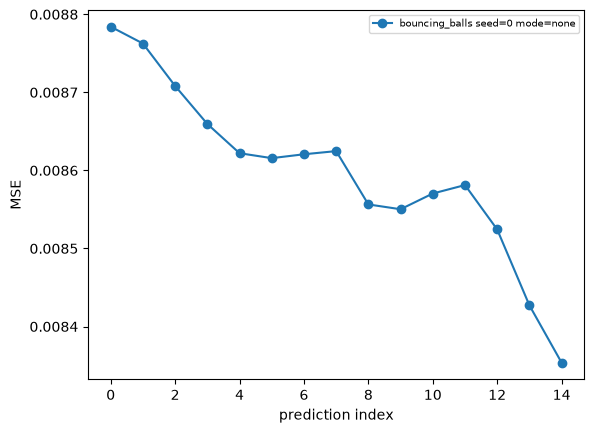

In [1]:
"ML pipeline + TDA - for SEQUENCES"
"""This cell keeps experiment orchestration in the notebook.
Reusable CNN/TDA classes and helpers live in topo.ml_tda."""
import importlib
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

import topo.config as topo_config
import topo.ml_tda as ml_tda
import topo.ml_tda_latent as latent_tda
importlib.reload(topo_config)
importlib.reload(ml_tda)
importlib.reload(latent_tda)
DATASET_CONFIGS = topo_config.DATASET_CONFIGS

from topo.ml_tda import (
    SpatialEncoder,
    SpatialDecoder,
    TopologicalPredictor,
    load_or_train_model,
    load_video_dataset,
    test_predictor,
)

DATASET = "bouncing_balls" # moving_mnist, davis_images, celltracking_fluo, bouncing_balls, glioblastoma, hela
PREDICT_STEPS_AHEAD = DATASET_CONFIGS[DATASET].get("PREDICT_STEPS_AHEAD", 1)

if DATASET_CONFIGS[DATASET].get("kind") != "ctc_tif_clips" and DATASET not in ["celltracking_davis", "celltracking_fluo"]:
    RUN_SEEDS        = DATASET_CONFIGS[DATASET].get("RUN_SEEDS", list(range(5)))
    LEGACY_TDA_MODES = ["none", "h0", "h1", "both"] # none, h0, h1, both
    RETRAIN_ENCODER  = False
    RETRAIN_PREDICTOR= True
    RUN_LATENT_TDA_IN_MAIN = True

    train_array, test_array = load_video_dataset(DATASET_CONFIGS[DATASET])
    X_train = torch.from_numpy(train_array).float().unsqueeze(2)
    X_test  = torch.from_numpy(test_array).float().unsqueeze(2)
    vid_len, batch_size, _, h_image, w_image = X_train.shape
    print(f"Dataset: {DATASET} | X_train: {X_train.shape} | X_test: {X_test.shape}")
    print(
        f"Input ranges: train min={X_train.min().item():.4f} max={X_train.max().item():.4f} mean={X_train.mean().item():.4f} | "
        f"test min={X_test.min().item():.4f} max={X_test.max().item():.4f} mean={X_test.mean().item():.4f}"
    )

    LATENT_DIM   = DATASET_CONFIGS[DATASET].get("LATENT_DIM", 128)
    HIDDEN_DIM   = DATASET_CONFIGS[DATASET].get("HIDDEN_DIM", 128)
    EPOCHS       = DATASET_CONFIGS[DATASET].get("EPOCHS", 10)
    LEARNING_RATE= DATASET_CONFIGS[DATASET].get("learning_rate", 3e-4)
    BETTI_SCALE  = DATASET_CONFIGS[DATASET].get("BETTI_SCALE", 15)
    N_STEPS      = DATASET_CONFIGS[DATASET].get("N_STEPS", 15) # #steps for Betti curve representation
    PREDICT_STEPS_AHEAD = DATASET_CONFIGS[DATASET].get("PREDICT_STEPS_AHEAD", 1)
    ml_tda.configure_runtime(
        DATASET=DATASET,
        LATENT_DIM=LATENT_DIM,
        BETTI_SCALE=BETTI_SCALE,
        N_STEPS=N_STEPS,
        PREDICT_STEPS_AHEAD=PREDICT_STEPS_AHEAD,
        EPOCHS=EPOCHS,
    )
    print(f"Runner config: seeds={RUN_SEEDS}, predict_steps_ahead={PREDICT_STEPS_AHEAD}, modes={LEGACY_TDA_MODES}")

    legacy_results = []
    legacy_runs    = {}

    for EXPERIMENT_SEED in RUN_SEEDS:
        print(f"\n================ legacy seed={EXPERIMENT_SEED} ================")
        random.seed(EXPERIMENT_SEED)
        np.random.seed(EXPERIMENT_SEED)
        torch.manual_seed(EXPERIMENT_SEED)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(EXPERIMENT_SEED)

        for TDA_MODE in LEGACY_TDA_MODES:
            ml_tda.configure_runtime(EXPERIMENT_SEED=EXPERIMENT_SEED, TDA_MODE=TDA_MODE)
            USE_TDA = TDA_MODE != "none"
            if TDA_MODE == "none":
                TDA_DIM = 0
            elif TDA_MODE in {"h0", "h1"}:
                TDA_DIM = N_STEPS
            else:
                TDA_DIM = 2 * N_STEPS
            INPUT_DIM = LATENT_DIM + TDA_DIM

            print(f"\n-------- DATASET={DATASET} seed={EXPERIMENT_SEED} TDA_MODE={TDA_MODE} --------")
            encoder  = SpatialEncoder(latent_dim=LATENT_DIM)
            decoder  = SpatialDecoder(latent_dim=LATENT_DIM, output_size=(h_image, w_image))
            model    = TopologicalPredictor(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM)
            criterion= nn.MSELoss()

            load_or_train_model(encoder, decoder, model, X_train, RETRAIN_ENCODER, RETRAIN_PREDICTOR, USE_TDA, LEARNING_RATE)
            test_mse, per_frame_mse = test_predictor(model, encoder, X_test, USE_TDA)
            row = {
                "dataset": DATASET,
                "seed": EXPERIMENT_SEED,
                "mode": TDA_MODE,
                "test_mse": float(test_mse),
                "warmup_excluded_mse": float(per_frame_mse[1:].mean()) if len(per_frame_mse) > 1 else float(test_mse),}
            legacy_results.append(row)
            legacy_runs[(EXPERIMENT_SEED, TDA_MODE)] = {"test_mse": test_mse, "per_frame_mse": per_frame_mse}
            print("legacy run summary:", row)

    legacy_results_df = pd.DataFrame(legacy_results)
    legacy_summary_df = ml_tda.summarize_metric_runs(
        legacy_results_df,
        group_cols="mode",
        metric_cols=["test_mse", "warmup_excluded_mse"],
        sort_metric="test_mse",
    )

    legacy_paired_df = legacy_results_df.pivot(index="seed", columns="mode", values="test_mse")
    if {"none", "h1"}.issubset(legacy_paired_df.columns):
        legacy_paired_df["h1_minus_none"] = legacy_paired_df["h1"] - legacy_paired_df["none"]
        print("\nPaired h1 - none differences; negative means h1 is better:")
        print(legacy_paired_df)
    print("\nLegacy per-run results:")
    print(legacy_results_df.to_string(index=False))
    print("\nLegacy mean +/- std by mode:")
    print(legacy_summary_df)
    display(legacy_summary_df)
    display(legacy_results_df.sort_values(["seed", "mode"]))

    if RUN_LATENT_TDA_IN_MAIN:
        LATENT_TDA_RUN_SEEDS = DATASET_CONFIGS[DATASET].get("RUN_SEEDS", list(range(5)))
        LATENT_TDA_MODES = ["z", "z_latent_h0", "z_latent_h1", "z_latent_both"]
        LATENT_TDA_WINDOW = DATASET_CONFIGS[DATASET].get("LATENT_TDA_WINDOW", 20)
        LATENT_TDA_BINS = DATASET_CONFIGS[DATASET].get("LATENT_TDA_BINS", 16)
        LATENT_TDA_EPOCHS = DATASET_CONFIGS[DATASET].get("LATENT_TDA_EPOCHS", 10)
        LATENT_TDA_LR = LEARNING_RATE
        LATENT_TDA_MAX_TRAIN = DATASET_CONFIGS[DATASET].get("LATENT_TDA_MAX_TRAIN")
        LATENT_TDA_MAX_TEST = DATASET_CONFIGS[DATASET].get("LATENT_TDA_MAX_TEST")
        RETRAIN_LATENT_TDA_PREDICTOR = DATASET_CONFIGS[DATASET].get("RETRAIN_LATENT_TDA_PREDICTOR", True)
        RECOMPUTE_LATENT_TDA_FEATURES = DATASET_CONFIGS[DATASET].get("RECOMPUTE_LATENT_TDA_FEATURES", True)

        latent_tda.configure_runtime(
            DATASET=DATASET,
            LATENT_DIM=LATENT_DIM,
            HIDDEN_DIM=HIDDEN_DIM,
            PREDICT_STEPS_AHEAD=PREDICT_STEPS_AHEAD,
            RETRAIN_ENCODER=False,
            LATENT_TDA_WINDOW=LATENT_TDA_WINDOW,
            LATENT_TDA_BINS=LATENT_TDA_BINS,
            LATENT_TDA_EPOCHS=LATENT_TDA_EPOCHS,
            LATENT_TDA_LR=LATENT_TDA_LR,
            RETRAIN_LATENT_TDA_PREDICTOR=RETRAIN_LATENT_TDA_PREDICTOR,
            RECOMPUTE_LATENT_TDA_FEATURES=RECOMPUTE_LATENT_TDA_FEATURES,
        )
        print(
            f"\nRunning TDA-on-latents: modes={LATENT_TDA_MODES}, "
            f"window={LATENT_TDA_WINDOW}, bins={LATENT_TDA_BINS}, "
            f"predict_steps_ahead={PREDICT_STEPS_AHEAD}"
        )
        latent_tda_results_df, latent_tda_summary_df, latent_tda_paired_df = latent_tda.run_latent_tda_trajectory_experiment(
            X_train=X_train,
            X_test=X_test,
            run_seeds=LATENT_TDA_RUN_SEEDS,
            modes=LATENT_TDA_MODES,
            max_train=LATENT_TDA_MAX_TRAIN,
            max_test=LATENT_TDA_MAX_TEST,
            display_fn=display,
        )


In [ ]:
"celltracking data loader + runner"
# Cache-first celltracking preprocessing + ablation runner.
# Reusable celltracking helpers live in topo.ml_tda_celltracking.
import importlib
import pandas as pd

import topo.config as topo_config
import topo.ml_tda_celltracking as ct_tda
importlib.reload(topo_config)
importlib.reload(ct_tda)
DATASET_CONFIGS = topo_config.DATASET_CONFIGS

from topo.ml_tda_celltracking import (
    compute_tda_features,
    encode_clips,
    features_for_latent_tda_mode,
    load_or_build_celltracking_tensors,
    load_or_compute_latent_tda_features,
    load_or_train_shared_encoder,
    make_latent_tda_supervised,
    make_supervised,
    prepare_clip_tensor_for_sequence_pipeline,
    set_all_seeds,
    tensor_range_text,
    train_mlp_variant,
)

CELLTRACKING_DATASET = "hela"
FORCE_REBUILD_CELLTRACKING_TENSORS = False
RECOMPUTE_CELLTRACKING_LATENT_TDA_FEATURES = False
celltracking_cfg = DATASET_CONFIGS[CELLTRACKING_DATASET]
RUN_CELLTRACKING_LATENT_TDA = celltracking_cfg.get("RUN_CELLTRACKING_LATENT_TDA", True)
CELLTRACKING_MODEL_NAME = f"{CELLTRACKING_DATASET}_clips"

train_tensor, test_tensor = load_or_build_celltracking_tensors(
    celltracking_cfg,
    force_rebuild=FORCE_REBUILD_CELLTRACKING_TENSORS,
)

print(f"Dataset: {CELLTRACKING_DATASET}")
print(f"Raw train_tensor: {tuple(train_tensor.shape)}")
print(f"Raw test_tensor:  {tuple(test_tensor.shape)}")
print(
    "Loaded tensor ranges: "
    f"{tensor_range_text('train', train_tensor)} | {tensor_range_text('test', test_tensor)}"
)

# Runner params come from topo/config.py so preprocessing and training stay aligned.
RUN_SEEDS = celltracking_cfg.get("RUN_SEEDS", list(range(5)))
MAX_TRAIN_CLIPS = celltracking_cfg.get("max_train_clips")
MAX_TEST_CLIPS = celltracking_cfg.get("max_test_clips")
PREDICT_STEPS_AHEAD = celltracking_cfg.get("PREDICT_STEPS_AHEAD", 5)
N_STEPS_LOCAL = celltracking_cfg.get("N_STEPS", 25)
BETTI_SCALE_LOCAL = celltracking_cfg.get("BETTI_SCALE", 15)
LATENT_DIM_LOCAL = celltracking_cfg.get("LATENT_DIM", 128)
AE_EPOCHS = celltracking_cfg.get("AE_EPOCHS", 2)
AE_MAX_FRAMES_PER_EPOCH = celltracking_cfg.get("AE_MAX_FRAMES_PER_EPOCH", 4096)
MLP_EPOCHS = celltracking_cfg.get("MLP_EPOCHS", 6)
MLP_BATCH_SIZE = celltracking_cfg.get("MLP_BATCH_SIZE", 512)
LEARNING_RATE = celltracking_cfg.get("learning_rate", 5e-4)
LATENT_TDA_WINDOW = celltracking_cfg.get("LATENT_TDA_WINDOW", 20)
LATENT_TDA_BINS = celltracking_cfg.get("LATENT_TDA_BINS", 16)
LATENT_TDA_MODES = ["z", "z_latent_h0", "z_latent_h1", "z_latent_both"]
ct_tda.configure_runtime(
    CELLTRACKING_MODEL_NAME=CELLTRACKING_MODEL_NAME,
    PREDICT_STEPS_AHEAD=PREDICT_STEPS_AHEAD,
    N_STEPS_LOCAL=N_STEPS_LOCAL,
    BETTI_SCALE_LOCAL=BETTI_SCALE_LOCAL,
    LATENT_DIM_LOCAL=LATENT_DIM_LOCAL,
    AE_EPOCHS=AE_EPOCHS,
    AE_MAX_FRAMES_PER_EPOCH=AE_MAX_FRAMES_PER_EPOCH,
    MLP_EPOCHS=MLP_EPOCHS,
    MLP_BATCH_SIZE=MLP_BATCH_SIZE,
    LEARNING_RATE=LEARNING_RATE,
)
print(
    f"Runner config: seeds={RUN_SEEDS}, max_train={MAX_TRAIN_CLIPS}, max_test={MAX_TEST_CLIPS}, "
    f"predict_steps_ahead={PREDICT_STEPS_AHEAD}, latent_dim={LATENT_DIM_LOCAL}, ae_epochs={AE_EPOCHS}, mlp_epochs={MLP_EPOCHS}"
)
if RUN_CELLTRACKING_LATENT_TDA:
    print(f"Latent TDA config: modes={LATENT_TDA_MODES}, window={LATENT_TDA_WINDOW}, bins={LATENT_TDA_BINS}")

INPUT_VARIANTS = {
    "no_tda": "z",
    "h1": "z_h1",
    "h0": "z_h0",
    "h0_h1": "z_h0_h1",
}
TASKS = ["next"]

ablation_rows = []
ablation_runs = {}
latent_tda_rows = []
latent_tda_runs = {}
for seed in RUN_SEEDS:
    print(f"\n================ ablation seed={seed} ================")
    set_all_seeds(seed)
    train_clips = prepare_clip_tensor_for_sequence_pipeline(train_tensor, MAX_TRAIN_CLIPS, seed=seed)
    test_clips = prepare_clip_tensor_for_sequence_pipeline(test_tensor, MAX_TEST_CLIPS, seed=seed + 1)
    print(f"Selected train clips: {tuple(train_clips.shape)} | test clips: {tuple(test_clips.shape)}")

    encoder, enc_path = load_or_train_shared_encoder(train_clips, test_clips, seed, dataset_name=CELLTRACKING_MODEL_NAME)
    z_train = encode_clips(encoder, train_clips)
    z_test = encode_clips(encoder, test_clips)

    h1_train = compute_tda_features(train_clips, homology_dim=1)
    h1_test = compute_tda_features(test_clips, homology_dim=1)
    h0_train = compute_tda_features(train_clips, homology_dim=0)
    h0_test = compute_tda_features(test_clips, homology_dim=0)

    for input_label, input_variant in INPUT_VARIANTS.items():
        for task in TASKS:
            label = f"{input_label}_{task}"
            print(f"\n--- {label} | seed={seed} ---")
            train_data = make_supervised(z_train, h1_train, h0_train, input_variant=input_variant, task=task)
            test_data = make_supervised(z_test, h1_test, h0_test, input_variant=input_variant, task=task)
            future_z_mse, target_mse = train_mlp_variant(label, train_data, test_data, seed, task=task)
            row = {
                "seed": seed,
                "input_variant": input_label,
                "task": task,
                "predict_steps_ahead": PREDICT_STEPS_AHEAD,
                "future_z_mse": future_z_mse,
                "target_mse": target_mse,
                "encoder_path": str(enc_path),
            }
            ablation_rows.append(row)
            ablation_runs[(seed, label)] = row
            print("ablation summary:", row)

    if RUN_CELLTRACKING_LATENT_TDA:
        train_payload = load_or_compute_latent_tda_features(
            CELLTRACKING_MODEL_NAME,
            seed,
            "train",
            z_train,
            window=LATENT_TDA_WINDOW,
            n_bins=LATENT_TDA_BINS,
            recompute=RECOMPUTE_CELLTRACKING_LATENT_TDA_FEATURES,
        )
        test_payload = load_or_compute_latent_tda_features(
            CELLTRACKING_MODEL_NAME,
            seed,
            "test",
            z_test,
            window=LATENT_TDA_WINDOW,
            n_bins=LATENT_TDA_BINS,
            recompute=RECOMPUTE_CELLTRACKING_LATENT_TDA_FEATURES,
        )
        for mode in LATENT_TDA_MODES:
            for task in TASKS:
                label = f"{mode}_{task}"
                print(f"\n--- latent {label} | seed={seed} ---")
                train_features = features_for_latent_tda_mode(train_payload, mode)
                test_features = features_for_latent_tda_mode(test_payload, mode)
                train_data = make_latent_tda_supervised(train_features, train_payload["z"], task=task)
                test_data = make_latent_tda_supervised(test_features, test_payload["z"], task=task)
                future_z_mse, target_mse = train_mlp_variant(label, train_data, test_data, seed, task=task)
                row = {
                    "seed": seed,
                    "input_variant": mode,
                    "task": task,
                    "predict_steps_ahead": PREDICT_STEPS_AHEAD,
                    "future_z_mse": future_z_mse,
                    "target_mse": target_mse,
                    "encoder_path": str(enc_path),
                }
                latent_tda_rows.append(row)
                latent_tda_runs[(seed, label)] = row
                print("latent TDA summary:", row)

ablation_results_df = pd.DataFrame(ablation_rows)
ablation_summary_df = (
    ablation_results_df
    .groupby(["input_variant", "task"])[["future_z_mse", "target_mse"]]
    .agg(["mean", "std"])
    .fillna(0.0)
    .sort_values(("future_z_mse", "mean"))
)

print("\nAblation per-run results:")
print(ablation_results_df.to_string(index=False))
print("\nAblation mean +/- std:")
print(ablation_summary_df)

display(ablation_summary_df)
display(ablation_results_df.sort_values(["seed", "future_z_mse"]))
ablation_results_df

if RUN_CELLTRACKING_LATENT_TDA:
    celltracking_latent_tda_results_df = pd.DataFrame(latent_tda_rows)
    celltracking_latent_tda_summary_df = (
        celltracking_latent_tda_results_df
        .groupby(["input_variant", "task"])[["future_z_mse", "target_mse"]]
        .agg(["mean", "std"])
        .fillna(0.0)
        .sort_values(("future_z_mse", "mean"))
    )
    print("\nCelltracking latent-TDA per-run results:")
    print(celltracking_latent_tda_results_df.to_string(index=False))
    print("\nCelltracking latent-TDA mean +/- std:")
    print(celltracking_latent_tda_summary_df)
    display(celltracking_latent_tda_summary_df)
    display(celltracking_latent_tda_results_df.sort_values(["seed", "future_z_mse"]))


In [ ]:
# GlaS non-sequential CNN + TDA classifier: multi-seed comparison
import random
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import cripser
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, roc_auc_score

IMAGE_SIZE = (64, 64)
LATENT_DIM = 128
HIDDEN_DIM = 128
N_STEPS = 25
BETTI_SCALE = 15
BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
SEEDS = [0, 1, 2, 3, 4]
TDA_MODES = ["none", "h1", "both"]  # add "h0" here if you want to keep tracking it
PRINT_EVERY = 5

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def group_glas_gland_data(folder_loc: str | Path, labels_file_name: str) -> pd.DataFrame:
    """Index GlaS images, masks, labels, split, and patient IDs."""
    root = Path(folder_loc)

    labels = pd.read_csv(root / labels_file_name)
    labels.columns = labels.columns.str.strip()

    grade_col = "grade (GlaS)"

    labels["name"] = labels["name"].astype(str).str.strip()
    labels[grade_col] = labels[grade_col].astype(str).str.strip().str.lower()
    labels["y"] = labels[grade_col].map({"benign": 0, "malignant": 1})

    bad = labels[labels["y"].isna()]
    if len(bad) > 0:
        print("Unmapped grades:")
        print(bad[["name", grade_col]])
        raise ValueError("Some grades could not be mapped to benign/malignant.")

    image_paths = {
        p.stem: p
        for p in root.glob("*.bmp")
        if "_anno" not in p.stem}

    mask_paths = {
        p.stem.replace("_anno", ""): p
        for p in root.glob("*_anno.bmp")}

    rows = []
    for _, r in labels.iterrows():
        name = r["name"]

        if name not in image_paths:
            raise FileNotFoundError(f"Missing image for {name}")
        if name not in mask_paths:
            raise FileNotFoundError(f"Missing mask for {name}")

        rows.append({
            "name": name,
            "patient_id": r["patient ID"],
            "grade_glas": r[grade_col],
            "y": int(r["y"]),
            "split": "train" if name.startswith("train") else "test",
            "image_path": image_paths[name],
            "mask_path": mask_paths[name],})
    return pd.DataFrame(rows).sort_values(["split", "name"]).reset_index(drop=True)

def load_grayscale_image(path, image_size=IMAGE_SIZE):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    image = cv2.resize(image, image_size[::-1], interpolation=cv2.INTER_AREA)
    image = image.astype(np.float32)
    if image.max() > 1.0:
        image /= 255.0
    return image

def load_mask_for_tda(path, image_size=IMAGE_SIZE):
    mask = load_grayscale_image(path, image_size=image_size)
    return (mask > 0).astype(np.float32)

def build_image_tensor(records, image_size=IMAGE_SIZE):
    images = [load_grayscale_image(path, image_size=image_size) for path in records["image_path"]]
    images = np.stack(images).astype(np.float32)
    return torch.from_numpy(images).unsqueeze(1).float()

def diagrams_to_betti_curve(diagram, num_steps=N_STEPS, min_v=0.0, max_v=1.0):
    thresholds = np.linspace(min_v, max_v, num_steps, dtype=np.float32)
    diagram = np.asarray(diagram, dtype=np.float32)
    curve = np.zeros(num_steps, dtype=np.float32)
    if diagram.size == 0:
        return curve
    diagram = diagram.reshape(-1, 2)
    diagram[~np.isfinite(diagram)] = max_v
    alive = (diagram[:, 0][:, None] <= thresholds) & (diagram[:, 1][:, None] > thresholds)
    curve = alive.sum(axis=0).astype(np.float32)
    return np.clip(curve / BETTI_SCALE, 0.0, 1.0)

def build_h0_h1_tda(records):
    h0_features, h1_features = [], []
    for i, mask_path in enumerate(records["mask_path"], start=1):
        if i == 1 or i % 25 == 0 or i == len(records):
            print(f"Computing mask TDA {i:03d}/{len(records):03d}")
        mask = load_mask_for_tda(mask_path)
        ph = cripser.compute_ph(mask.astype(np.float32), maxdim=1)
        h0 = ph[ph[:, 0] == 0][:, 1:3]
        h1 = ph[ph[:, 0] == 1][:, 1:3]
        h0_features.append(diagrams_to_betti_curve(h0))
        h1_features.append(diagrams_to_betti_curve(h1))
    h0_tensor = torch.tensor(np.stack(h0_features), dtype=torch.float32)
    h1_tensor = torch.tensor(np.stack(h1_features), dtype=torch.float32)
    return h0_tensor, h1_tensor

def select_tda_features(h0_tensor, h1_tensor, mode):
    if mode == "none":
        return torch.zeros((h0_tensor.shape[0], 0), dtype=torch.float32)
    if mode == "h0":
        return h0_tensor.float()
    if mode == "h1":
        return h1_tensor.float()
    if mode == "both":
        return torch.cat([h0_tensor, h1_tensor], dim=1).float()
    raise ValueError('mode must be "none", "h0", "h1", or "both"')

class GlasTensorDataset(Dataset):
    def __init__(self, images, tda_features, labels):
        self.images = images.float()
        self.tda_features = tda_features.float()
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.tda_features[idx], self.labels[idx]

class GlasCNNEncoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.fc = nn.Linear(32 * 4 * 4, latent_dim)

    def forward(self, x):
        x = self.conv_layers(x)
        x = torch.flatten(x, start_dim=1)
        return self.fc(x)

class GlasCNNWithTDA(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, tda_dim=0, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.encoder = GlasCNNEncoder(latent_dim=latent_dim)
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim + tda_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, image, tda):
        z = self.encoder(image)
        fused = torch.cat([z, tda], dim=1)
        return self.classifier(fused).squeeze(1)

def run_epoch(model, loader, criterion, optimizer=None, device="cpu"):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    all_probs, all_y = [], []
    for image, tda, y in loader:
        image = image.to(device)
        tda = tda.to(device)
        y = y.to(device)
        if is_train:
            optimizer.zero_grad()
        logits = model(image, tda)
        loss = criterion(logits, y)
        if is_train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(y)
        all_probs.append(torch.sigmoid(logits).detach().cpu())
        all_y.append(y.detach().cpu())
    probs = torch.cat(all_probs).numpy()
    y_true = torch.cat(all_y).numpy().astype(int)
    y_pred = (probs >= 0.5).astype(int)
    metrics = {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }
    if len(np.unique(y_true)) == 2:
        metrics["roc_auc"] = roc_auc_score(y_true, probs)
    return metrics, probs, y_true

def train_one_run(mode, seed, train_images, test_images, train_tda, test_tda, device):
    set_seed(seed)
    train_labels = train_df["y"].to_numpy(dtype=np.float32)
    test_labels = test_df["y"].to_numpy(dtype=np.float32)

    train_dataset = GlasTensorDataset(train_images, train_tda, train_labels)
    test_dataset = GlasTensorDataset(test_images, test_tda, test_labels)
    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = GlasCNNWithTDA(latent_dim=LATENT_DIM, tda_dim=train_tda.shape[1], hidden_dim=HIDDEN_DIM).to(device)
    num_pos = float((train_df["y"] == 1).sum())
    num_neg = float((train_df["y"] == 0).sum())
    pos_weight = torch.tensor([num_neg / max(num_pos, 1.0)], dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    for epoch in range(1, EPOCHS + 1):
        train_metrics, _, _ = run_epoch(model, train_loader, criterion, optimizer=optimizer, device=device)
        test_metrics, _, _ = run_epoch(model, test_loader, criterion, optimizer=None, device=device)
        should_print = epoch == 1 or epoch == EPOCHS or epoch % PRINT_EVERY == 0
        if should_print:
            print(
                f"mode={mode:>4} seed={seed} epoch={epoch:02d}/{EPOCHS} | "
                f"train auc {train_metrics.get('roc_auc', np.nan):.3f} | "
                f"test auc {test_metrics.get('roc_auc', np.nan):.3f} "
                f"bal_acc {test_metrics['balanced_accuracy']:.3f}"
            )

    final_metrics, test_probs, test_y = run_epoch(model, test_loader, criterion, optimizer=None, device=device)
    y_pred = (test_probs >= 0.5).astype(int)
    result = {"mode": mode, "seed": seed, **final_metrics}
    return result, test_probs, test_y, y_pred, model

df       = group_glas_gland_data("datasets/2D/glas_gland", "Grade.csv")
train_df = df[df["split"] == "train"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

# df is created in the previous GlaS indexing cell.
required_columns = {"split", "image_path", "mask_path", "y"}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"df is missing required columns: {sorted(missing_columns)}")

train_df = df[df["split"] == "train"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)
if train_df.empty or test_df.empty:
    raise ValueError("Both train_df and test_df must be non-empty. Check df['split'].")

print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)}")
print("Train labels:")
print(train_df["y"].value_counts().rename(index={0: "benign", 1: "malignant"}))
print("Test labels:")
print(test_df["y"].value_counts().rename(index={0: "benign", 1: "malignant"}))

print("Loading image tensors...")
train_images = build_image_tensor(train_df)
test_images = build_image_tensor(test_df)

print("Computing reusable train TDA features...")
train_h0, train_h1 = build_h0_h1_tda(train_df)
print("Computing reusable test TDA features...")
test_h0, test_h1 = build_h0_h1_tda(test_df)

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")
print(f"Modes: {TDA_MODES} | Seeds: {SEEDS} | Epochs: {EPOCHS}")

all_results = []
last_run = {}
for mode in TDA_MODES:
    train_tda = select_tda_features(train_h0, train_h1, mode)
    test_tda = select_tda_features(test_h0, test_h1, mode)
    print(f"\n=== TDA_MODE={mode} | TDA dim={train_tda.shape[1]} ===")
    for seed in SEEDS:
        result, test_probs, test_y, y_pred, model = train_one_run(
            mode, seed, train_images, test_images, train_tda, test_tda, device
        )
        all_results.append(result)
        last_run = {
            "mode": mode,
            "seed": seed,
            "model": model,
            "test_probs": test_probs,
            "test_y": test_y,
            "y_pred": y_pred,}
        print(f"final mode={mode:>4} seed={seed} | {result}")

results_df = pd.DataFrame(all_results)
summary_df = (
    results_df
    .groupby("mode")[["loss", "accuracy", "balanced_accuracy", "roc_auc"]]
    .agg(["mean", "std"])
    .sort_values(("roc_auc", "mean"), ascending=False))

best_idx = results_df["roc_auc"].idxmax()
best_run = results_df.loc[best_idx].to_dict()
print("\nPer-run results:")
print(results_df.sort_values(["mode", "seed"]).to_string(index=False))
print("\nMean +/- std by mode:")
print(summary_df)
print("\nBest single run:", best_run)

# Predictions from the final run in the loop, useful for quick inspection.
test_predictions = test_df[["name", "split", "image_path", "mask_path", "y"]].copy()
test_predictions["mode"] = last_run["mode"]
test_predictions["seed"] = last_run["seed"]
test_predictions["prob_malignant"] = last_run["test_probs"]
test_predictions["pred_y"] = last_run["y_pred"]
print("\nFinal loop run confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(last_run["test_y"], last_run["y_pred"]))

display(summary_df)
display(results_df.sort_values("roc_auc", ascending=False))
# test_predictions.head()


In [ ]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

def load_lightweight_vortex_stack(mat_file_path):
    """
    Loads Raissi's 2D cylinder wake data and reshapes it into a (T, C, H, W) video stack.
    """
    # 1. Load the MATLAB file
    data = scipy.io.loadmat(mat_file_path)
    
    # Extract raw arrays
    # U_star shape is typically (N_points, 2_components, T_timesteps)
    U_star = data['U_star'] 
    X_star = data['X_star'] # (N_points, 2)
    
    # 2. Determine grid dimensions by finding unique spatial coordinates
    x_coords = np.unique(X_star[:, 0])
    y_coords = np.unique(X_star[:, 1])
    H_len, W_len = len(y_coords), len(x_coords)
    T_len = U_star.shape[2]
    
    # 3. Extract velocity magnitude (or vorticity) as your scalar pixel intensity
    # U_star[:, 0, :] is horizontal velocity; U_star[:, 1, :] is vertical velocity
    velocity_magnitude = np.sqrt(U_star[:, 0, :]**2 + U_star[:, 1, :]**2) # (N_points, T)
    
    # 4. Reshape into a structured spatial grid over time
    # Transpose to put Time first -> (T, H, W)
    video_stack = np.zeros((T_len, H_len, W_len))
    for t in range(T_len):
        # Map the flattened spatial points back into a 2D mesh layout
        grid = velocity_magnitude[:, t].reshape((W_len, H_len)).T
        video_stack[t] = grid
        
    # 5. Add the channel dimension for your pipeline -> (T, 1, H, W)
    video_stack = video_stack[:, np.newaxis, :, :]
    
    print(f"Fluid vortex stack loaded. Shape: {video_stack.shape}")
    return video_stack

# --- Execution ---
# stack = load_lightweight_vortex_stack("datasets/2D/cylinder_nektar_wake.mat")
# patches = slice_video_into_spatial_patches(stack, patch_size=64)
# np.save("datasets/2D/cylinder_vortex_stack.npy", stack)
if vortex_stack is None:
    vortex_stack = np.load("datasets/2D/cylinder_vortex_stack.npy")

plt.imshow(vortex_stack[199, 0], cmap="viridis")



In [2]:
# xLSTM sequence predictor ablation: none / h0 / h1 / both
# Run the main "ML pipeline + TDA - for SEQUENCES" cell first so X_train/X_test/config globals exist.
import importlib
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import topo.ml_tda as ml_tda
importlib.reload(ml_tda)

from topo.ml_tda import (
    SpatialEncoder,
    SpatialDecoder,
    build_sequence_features,
    pretrain_spatial_encoder,
    summarize_metric_runs,
)
from xlstm import xLSTMBlockStack, xLSTMBlockStackConfig, mLSTMBlockConfig, mLSTMLayerConfig


class XLSTMFuturePredictor(nn.Module):
    """Predict a future latent vector from a context window of z/TDA features."""

    def __init__(self, input_dim, latent_dim, hidden_dim=128, context_len=10, n_layers=2, dropout=0.1):
        super().__init__()
        self.in_proj = nn.Linear(input_dim, hidden_dim)
        cfg = xLSTMBlockStackConfig(
            mlstm_block=mLSTMBlockConfig(
                mlstm=mLSTMLayerConfig(
                    conv1d_kernel_size=4,
                    qkv_proj_blocksize=4,
                    num_heads=4,
                ),
            ),
            context_length=context_len,
            num_blocks=n_layers,
            embedding_dim=hidden_dim,
            dropout=dropout,
        )
        self.xlstm = xLSTMBlockStack(cfg)
        self.head = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        # x: (N, context_len, input_dim)
        h = self.in_proj(x)
        h = self.xlstm(h)
        return self.head(h[:, -1])


def set_xlstm_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_xlstm_windows(feature_seq, z_seq, context_len, predict_steps_ahead, max_windows=None, seed=0):
    """Convert (T,B,D) features and (T,B,L) z into supervised windows."""
    T, B = feature_seq.shape[:2]
    if context_len + predict_steps_ahead > T:
        raise ValueError(
            f"context_len + predict_steps_ahead must be <= sequence length; "
            f"got {context_len}+{predict_steps_ahead}>{T}"
        )

    xs, ys = [], []
    for start in range(0, T - context_len - predict_steps_ahead + 1):
        end = start + context_len
        target_t = end - 1 + predict_steps_ahead
        xs.append(feature_seq[start:end].permute(1, 0, 2))  # (B, context, D)
        ys.append(z_seq[target_t])                         # (B, latent)
    x = torch.cat(xs, dim=0).float()
    y = torch.cat(ys, dim=0).float()

    if max_windows is not None and len(x) > max_windows:
        generator = torch.Generator().manual_seed(seed)
        idx = torch.randperm(len(x), generator=generator)[:max_windows]
        x = x[idx]
        y = y[idx]
    return x, y


def load_or_train_xlstm_encoder(seed):
    encoder = SpatialEncoder(latent_dim=LATENT_DIM)
    decoder = SpatialDecoder(latent_dim=LATENT_DIM, output_size=X_train.shape[-2:])
    encoder_dir = Path("models") / DATASET / "encoders"
    encoder_dir.mkdir(parents=True, exist_ok=True)
    encoder_tag = (
        f"seed{seed}_T{X_train.shape[0]}_B{X_train.shape[1]}_"
        f"H{X_train.shape[-2]}_W{X_train.shape[-1]}_latent{LATENT_DIM}"
    )
    encoder_path = encoder_dir / f"encoder_{encoder_tag}.pt"

    if encoder_path.exists() and not XLSTM_RETRAIN_ENCODER:
        print(f"Loading shared encoder for xLSTM: {encoder_path}")
        encoder.load_state_dict(torch.load(encoder_path, map_location="cpu"))
    else:
        reason = "retraining" if encoder_path.exists() else "missing; training once"
        print(f"Shared encoder for xLSTM {reason}: {encoder_path}")
        pretrain_spatial_encoder(encoder, decoder, X_train, epochs=3)
        torch.save(encoder.state_dict(), encoder_path)
        print(f"Saved shared encoder: {encoder_path}")

    encoder.eval()
    for p in encoder.parameters():
        p.requires_grad = False
    return encoder, encoder_path


def build_xlstm_feature_cache(video_tensor, encoder, modes, split_name):
    """Build z/H0/H1 features once, then assemble each requested xLSTM mode."""
    ml_tda.configure_runtime(TDA_MODE="none")
    z_only, z_seq = build_sequence_features(video_tensor, encoder, use_tda=False, split_name=f"{split_name} none")
    cache = {"none": z_only}

    needs_tda = any(mode in {"h0", "h1", "both"} for mode in modes)
    if needs_tda:
        ml_tda.configure_runtime(TDA_MODE="both")
        both_features, _ = build_sequence_features(video_tensor, encoder, use_tda=True, split_name=f"{split_name} h0+h1 cache")
        h0 = both_features[..., LATENT_DIM:LATENT_DIM + N_STEPS]
        h1 = both_features[..., LATENT_DIM + N_STEPS:LATENT_DIM + 2 * N_STEPS]
        cache["h0"] = torch.cat([z_seq, h0], dim=-1)
        cache["h1"] = torch.cat([z_seq, h1], dim=-1)
        cache["both"] = torch.cat([z_seq, h0, h1], dim=-1)
    return cache, z_seq


def train_eval_xlstm_variant(mode, train_features, train_z, test_features, test_z, seed):
    context_len = min(XLSTM_CONTEXT_LEN, train_features.shape[0] - PREDICT_STEPS_AHEAD)
    if context_len < 2:
        raise ValueError("xLSTM context_len resolved below 2; reduce PREDICT_STEPS_AHEAD or increase sequence length")

    x_train_win, y_train_win = make_xlstm_windows(
        train_features, train_z, context_len, PREDICT_STEPS_AHEAD,
        max_windows=XLSTM_MAX_TRAIN_WINDOWS, seed=seed,
    )
    x_test_win, y_test_win = make_xlstm_windows(
        test_features, test_z, context_len, PREDICT_STEPS_AHEAD,
        max_windows=XLSTM_MAX_TEST_WINDOWS, seed=seed + 1,
    )

    model = XLSTMFuturePredictor(
        input_dim=x_train_win.shape[-1],
        latent_dim=LATENT_DIM,
        hidden_dim=XLSTM_HIDDEN_DIM,
        context_len=context_len,
        n_layers=XLSTM_LAYERS,
        dropout=XLSTM_DROPOUT,
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=XLSTM_LR, weight_decay=XLSTM_WEIGHT_DECAY)
    criterion = nn.MSELoss()
    loader = DataLoader(TensorDataset(x_train_win, y_train_win), batch_size=XLSTM_BATCH_SIZE, shuffle=True)

    for epoch in range(1, XLSTM_EPOCHS + 1):
        model.train()
        total, seen = 0.0, 0
        for xb, yb in loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total += loss.item() * len(xb)
            seen += len(xb)
        if epoch == 1 or epoch == XLSTM_EPOCHS:
            print(f"xLSTM {mode} seed={seed} epoch {epoch}/{XLSTM_EPOCHS} train MSE {total / seen:.6f}")

    model.eval()
    with torch.no_grad():
        pred = model(x_test_win)
        test_mse = criterion(pred, y_test_win).item()
        per_sample_mse = ((pred - y_test_win) ** 2).mean(dim=1).cpu()
    return test_mse, per_sample_mse, context_len, len(x_train_win), len(x_test_win)


required = ["X_train", "X_test", "DATASET", "DATASET_CONFIGS", "LATENT_DIM", "HIDDEN_DIM", "PREDICT_STEPS_AHEAD"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run the main sequence ML pipeline cell first. Missing globals: {missing}")

XLSTM_MODES = ["none", "h0", "h1"]
XLSTM_RUN_SEEDS = DATASET_CONFIGS[DATASET].get("RUN_SEEDS", list(range(3)))
XLSTM_CONTEXT_LEN = DATASET_CONFIGS[DATASET].get("XLSTM_CONTEXT_LEN", min(10, X_train.shape[0] - PREDICT_STEPS_AHEAD))
XLSTM_HIDDEN_DIM = DATASET_CONFIGS[DATASET].get("XLSTM_HIDDEN_DIM", HIDDEN_DIM)
XLSTM_LAYERS = DATASET_CONFIGS[DATASET].get("XLSTM_LAYERS", 2)
XLSTM_DROPOUT = DATASET_CONFIGS[DATASET].get("XLSTM_DROPOUT", 0.1)
XLSTM_EPOCHS = DATASET_CONFIGS[DATASET].get("XLSTM_EPOCHS", 6)
XLSTM_LR = DATASET_CONFIGS[DATASET].get("XLSTM_LR", LEARNING_RATE if "LEARNING_RATE" in globals() else 3e-4)
XLSTM_WEIGHT_DECAY = DATASET_CONFIGS[DATASET].get("XLSTM_WEIGHT_DECAY", 1e-4)
XLSTM_BATCH_SIZE = DATASET_CONFIGS[DATASET].get("XLSTM_BATCH_SIZE", 64)
XLSTM_MAX_TRAIN_WINDOWS = DATASET_CONFIGS[DATASET].get("XLSTM_MAX_TRAIN_WINDOWS")
XLSTM_MAX_TEST_WINDOWS = DATASET_CONFIGS[DATASET].get("XLSTM_MAX_TEST_WINDOWS")
XLSTM_RETRAIN_ENCODER = False

print(
    f"xLSTM config: dataset={DATASET}, seeds={XLSTM_RUN_SEEDS}, modes={XLSTM_MODES}, "
    f"context_len={XLSTM_CONTEXT_LEN}, predict_steps_ahead={PREDICT_STEPS_AHEAD}, "
    f"hidden={XLSTM_HIDDEN_DIM}, layers={XLSTM_LAYERS}, epochs={XLSTM_EPOCHS}, "
    f"max_train_windows={XLSTM_MAX_TRAIN_WINDOWS}, max_test_windows={XLSTM_MAX_TEST_WINDOWS}"
)

xlstm_rows = []
for seed in XLSTM_RUN_SEEDS:
    print(f"\n================ xLSTM seed={seed} ================")
    set_xlstm_seed(seed)
    ml_tda.configure_runtime(
        DATASET=DATASET,
        EXPERIMENT_SEED=seed,
        LATENT_DIM=LATENT_DIM,
        BETTI_SCALE=BETTI_SCALE,
        N_STEPS=N_STEPS,
        PREDICT_STEPS_AHEAD=PREDICT_STEPS_AHEAD,
        EPOCHS=EPOCHS,
    )

    ml_tda.configure_runtime(TDA_MODE="none")
    encoder, encoder_path = load_or_train_xlstm_encoder(seed)

    train_feature_cache, train_z = build_xlstm_feature_cache(X_train, encoder, XLSTM_MODES, split_name="xLSTM train")
    test_feature_cache, test_z = build_xlstm_feature_cache(X_test, encoder, XLSTM_MODES, split_name="xLSTM test")

    for mode in XLSTM_MODES:
        print(f"\n--- xLSTM mode={mode} seed={seed} ---")
        train_features = train_feature_cache[mode]
        test_features = test_feature_cache[mode]
        test_mse, per_sample_mse, context_len, n_train, n_test = train_eval_xlstm_variant(
            mode, train_features, train_z, test_features, test_z, seed
        )
        row = {
            "dataset": DATASET,
            "seed": seed,
            "mode": mode,
            "predict_steps_ahead": PREDICT_STEPS_AHEAD,
            "context_len": context_len,
            "train_windows": n_train,
            "test_windows": n_test,
            "test_mse": float(test_mse),
            "per_sample_mse_mean": float(per_sample_mse.mean()),
            "encoder_path": str(encoder_path),
        }
        xlstm_rows.append(row)
        print("xLSTM summary:", row)

xlstm_results_df = pd.DataFrame(xlstm_rows)
xlstm_summary_df = summarize_metric_runs(
    xlstm_results_df,
    group_cols="mode",
    metric_cols=["test_mse", "per_sample_mse_mean"],
    sort_metric="test_mse",
)
print("\nxLSTM per-run results:")
print(xlstm_results_df.to_string(index=False))
print("\nxLSTM mean +/- std:")
print(xlstm_summary_df)
display(xlstm_summary_df)
display(xlstm_results_df.sort_values(["seed", "mode"]))

xLSTM config: dataset=bouncing_balls, seeds=[0, 1, 2, 3, 4], modes=['none', 'h0', 'h1'], context_len=10, predict_steps_ahead=15, hidden=96, layers=2, epochs=6, max_train_windows=512, max_test_windows=344

================ xLSTM seed=0 ================
Loading shared encoder for xLSTM: models/bouncing_balls/encoders/encoder_seed0_T30_B96_H128_W128_latent64.pt
  [xLSTM train h0+h1 cache Frame 01/30] Computing TDA
  [xLSTM train h0+h1 cache Frame 20/30] Computing TDA
  [xLSTM train h0+h1 cache Frame 30/30] Computing TDA
  [xLSTM test h0+h1 cache Frame 01/30] Computing TDA
  [xLSTM test h0+h1 cache Frame 20/30] Computing TDA
  [xLSTM test h0+h1 cache Frame 30/30] Computing TDA

--- xLSTM mode=none seed=0 ---
xLSTM none seed=0 epoch 1/6 train MSE 0.130818
xLSTM none seed=0 epoch 6/6 train MSE 0.021215
xLSTM summary: {'dataset': 'bouncing_balls', 'seed': 0, 'mode': 'none', 'predict_steps_ahead': 15, 'context_len': 10, 'train_windows': 512, 'test_windows': 192, 'test_mse': 0.00082051753997802

test_mse              per_sample_mse_mean             
          mean       std  n                mean       std  n
mode                                                        
none  0.000689  0.000120  5            0.000689  0.000120  5
h1    0.001006  0.000119  5            0.001006  0.000119  5
h0    0.001118  0.000178  5            0.001118  0.000178  5

,dataset,seed,mode,predict_steps_ahead,context_len,train_windows,test_windows,test_mse,per_sample_mse_mean,encoder_path
1,bouncing_balls,0,h0,15,10,512,192,0.001262,0.001262,models/bouncing_balls/encoders/encoder_seed0_T...
2,bouncing_balls,0,h1,15,10,512,192,0.001035,0.001035,models/bouncing_balls/encoders/encoder_seed0_T...
0,bouncing_balls,0,none,15,10,512,192,0.000821,0.000821,models/bouncing_balls/encoders/encoder_seed0_T...
4,bouncing_balls,1,h0,15,10,512,192,0.001319,0.001319,models/bouncing_balls/encoders/encoder_seed1_T...
5,bouncing_balls,1,h1,15,10,512,192,0.000965,0.000965,models/bouncing_balls/encoders/encoder_seed1_T...
3,bouncing_balls,1,none,15,10,512,192,0.000767,0.000767,models/bouncing_balls/encoders/encoder_seed1_T...
7,bouncing_balls,2,h0,15,10,512,192,0.001171,0.001171,models/bouncing_balls/encoders/encoder_seed2_T...
8,bouncing_balls,2,h1,15,10,512,192,0.001011,0.001011,models/bouncing_balls/encoders/encoder_seed2_T...
6,bouncing_balls,2,none,15,10,512,192,0.000552,0.000552,models/bouncing_balls/encoders/encoder_seed2_T...
10,bouncing_balls,3,h0,15,10,512,192,0.000829,0.000829,models/bouncing_balls/encoders/encoder_seed3_T...
